## 1. Import Requirements

# Master Shear-Wave Splitting Workflow for Axial Seamount

This notebook provides a complete, clean workflow from raw earthquake catalog and waveform data to shear-wave splitting analysis results. The workflow follows proper sequencing and includes all necessary quality control measures. 

Instead of using catalog from Wilcock and Zhang or ML DD, we use the nlloc file for all stations from Christian's results.

## Workflow Overview

1. **Data Loading & Initial Setup** - Load earthquake catalog and station metadata
2. **Extended Time Window Creation** - Create proper time windows for waveform retrieval
3. **Waveform Data Retrieval** - Download seismic data with extended windows
4. **Quality Control Filters** - P-wave rectilinearity, SNR, and incidence angle filtering
5. **Geometric Calculations** - Back-azimuth and distance calculations
6. **Shear-Wave Splitting Analysis** - Dynamic parameter estimation and SWSPy analysis
7. **Results Processing & Visualization** - Compile and visualize splitting parameters

## Key Improvements
- Extended catalog creation moved to proper early position
- Updated P-wave polarization analysis for true incidence angles
- Integrated SNR calculations with proper S-wave timing
- Clean separation of quality control steps

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy.core.utcdatetime import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.event import read_events
import os
import sys
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add local swspy directory to path (before other imports)
swspy_local_path = os.path.abspath('../swspy')
if swspy_local_path not in sys.path:
    sys.path.insert(0, swspy_local_path)

# Import swspy from local directory
import swspy

# Add scripts directory to path for custom modules
sys.path.append('.')
from get_all_traces import get_station_traces_batch
from splitting_functions import *
from teanby_clustering import *

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully")
print(f"ObsPy version: {obspy.__version__}")
print(f"SWSPy available: {'Yes' if 'swspy' in sys.modules else 'No'}")
print(f"SWSPy location: {swspy.__file__}")

mtspec not available, using ObsPy PPSD method
Libraries imported successfully
ObsPy version: 1.4.2
SWSPy available: Yes
SWSPy location: /Users/mhemmett/Seismology/axial-splitting-ml/swspy/swspy/__init__.py


In [2]:
# Load Kaiwen's ML DD catalog
catalog_file = '../data/mldd_catalog_2015_2021.csv'

catalog = pd.read_csv(catalog_file)

#Load station information from Christian's data
stations_file = '../data/stations_axial.llz'
#Read llz file - reads like a text file with space delimiter
stations_df = pd.read_csv(stations_file, delim_whitespace=True, header=None, names=['Longitude (°W)', 'Latitude (°N)', 'Elevation (m)', 'Station ID'])
# Convert elevation column to m from km
stations_df['Elevation (m)'] = stations_df['Elevation (m)']*1000

print(f"Stations in catalog: {catalog['station'].value_counts()}")

Stations in catalog: station
AXEC3    131851
AXEC1    125620
AXEC2    124144
AXAS1     77793
AXCC1     74252
AXAS2     51614
Name: count, dtype: int64


In [3]:

# Look at AXEC2 station
axec2_catalog = catalog[catalog['station'] == 'AXEC2'].copy()

# Reset index to ensure clean indexing
axec2_catalog = axec2_catalog.reset_index(drop=True)

axec2_catalog['datetime'] = pd.to_datetime(axec2_catalog['event_datetime'], format='ISO8601')

#print(f"Total AXAS2 events in catalog: {len(axas2_catalog)}")
print(f"Total AXEC2 events in catalog: {len(axec2_catalog)}")

print(f"\nDate range of test catalog:")
print(f"Start: {axec2_catalog['datetime'].min()}")
print(f"End: {axec2_catalog['datetime'].max()}")

display(axec2_catalog)

Total AXEC2 events in catalog: 124144

Date range of test catalog:
Start: 2015-01-22 00:00:26.665000+00:00
End: 2021-12-30 14:04:17.500000+00:00


,station,arrival_time_p,event_datetime,arrival_time_s,event_lat,event_lon,event_depth,event_magnitude,datetime
0,AXEC2,0.985,2015-01-22 00:00:26.665000+00:00,2.205,45.972469,-129.990463,0.150,0.0,2015-01-22 00:00:26.665000+00:00
1,AXEC2,0.818,2015-01-22 00:11:48.772000+00:00,1.648,45.941242,-130.013107,0.505,0.0,2015-01-22 00:11:48.772000+00:00
2,AXEC2,0.855,2015-01-22 02:02:41.045000+00:00,1.605,45.941704,-130.012985,0.529,0.0,2015-01-22 02:02:41.045000+00:00
3,AXEC2,0.495,2015-01-22 02:19:57.135000+00:00,1.335,45.919773,-129.968887,0.739,0.0,2015-01-22 02:19:57.135000+00:00
4,AXEC2,-0.595,2015-01-22 02:32:50.005000+00:00,1.375,45.960056,-129.992371,1.664,0.0,2015-01-22 02:32:50.005000+00:00
...,...,...,...,...,...,...,...,...,...
124139,AXEC2,0.561,2021-12-28 15:38:47.109000+00:00,1.151,45.925873,-129.983963,1.107,0.0,2021-12-28 15:38:47.109000+00:00
124140,AXEC2,0.500,2021-12-28 20:02:15.720000+00:00,1.000,45.945759,-129.990723,0.532,0.0,2021-12-28 20:02:15.720000+00:00
124141,AXEC2,0.875,2021-12-29 00:09:14.415000+00:00,1.685,45.941311,-130.020645,1.009,0.0,2021-12-29 00:09:14.415000+00:00
124142,AXEC2,0.647,2021-12-29 00:52:01.473000+00:00,1.177,45.952965,-129.996658,0.372,0.0,2021-12-29 00:52:01.473000+00:00


In [4]:

test_catalog = axec2_catalog.copy()

print(f"\nDate range of test catalog:")
print(f"Start: {test_catalog['datetime'].min()}")
print(f"End: {test_catalog['datetime'].max()}")


Date range of test catalog:
Start: 2015-01-22 00:00:26.665000+00:00
End: 2021-12-30 14:04:17.500000+00:00


In [5]:
# Convert to UTCDateTime
test_catalog['datetime'] = test_catalog['datetime'].apply(lambda x: UTCDateTime(x))

# Format p_time and s_time as UTCDateTime of datetime + p_arrival_time and s_arrival_time, respectively
# Format p_time and s_time as UTCDateTime of datetime + p_time and s_time, respectively
test_catalog['p_time'] = test_catalog.apply(lambda row: UTCDateTime(row['datetime']) + row['arrival_time_p'], axis=1)
test_catalog['s_time'] = test_catalog.apply(lambda row: UTCDateTime(row['datetime']) + row['arrival_time_s'], axis=1)

print("Successfully converted p_time and s_time to absolute UTCDateTime")
print(f"Sample p_time: {test_catalog['p_time'].iloc[0]}")
print(f"Sample s_time: {test_catalog['s_time'].iloc[0]}")


Successfully converted p_time and s_time to absolute UTCDateTime
Sample p_time: 2015-01-22T00:00:27.650000Z
Sample s_time: 2015-01-22T00:00:28.870000Z


In [6]:
catalog = test_catalog.copy()

In [7]:
catalog['event_id'] = catalog.index

## 3. Extended Time Window Creation

This step creates extended time windows for waveform retrieval. This is critical for proper analysis and must happen early in the workflow, before any quality control that depends on waveform data.

In [8]:
# Create extended time windows for proper waveform analysis
print("Creating extended time windows for waveform retrieval...")

# Apply extended windowing
extended_catalog = create_extended_catalog(catalog, pre_p_time=1.0, post_s_time=2.0)

print(f"Extended catalog created with {len(extended_catalog)} events")
print(f"Time windows: {extended_catalog['total_duration'].iloc[0]} seconds total")
print(f"Pre-event: {extended_catalog['pre_p_sec'].iloc[0]}s, Post-event: {extended_catalog['post_s_sec'].iloc[0]}s")
# Display sample of extended timing
print("\nSample timing windows:")
sample_cols = ['event_id', 'datetime', 'starttime', 'endtime', 'total_duration']
display(extended_catalog[sample_cols].head())

Creating extended time windows for waveform retrieval...
Extended catalog created with 124144 events
Time windows: 4.22 seconds total
Pre-event: 1.0s, Post-event: 2.0s

Sample timing windows:


,event_id,datetime,starttime,endtime,total_duration
0,0,2015-01-22T00:00:26.665000Z,2015-01-22T00:00:26.650000Z,2015-01-22T00:00:30.870000Z,4.22
1,1,2015-01-22T00:11:48.772000Z,2015-01-22T00:11:48.590000Z,2015-01-22T00:11:52.420000Z,3.83
2,2,2015-01-22T02:02:41.045000Z,2015-01-22T02:02:40.900000Z,2015-01-22T02:02:44.650000Z,3.75
3,3,2015-01-22T02:19:57.135000Z,2015-01-22T02:19:56.630000Z,2015-01-22T02:20:00.470000Z,3.84
4,4,2015-01-22T02:32:50.005000Z,2015-01-22T02:32:48.410000Z,2015-01-22T02:32:53.380000Z,4.97


In [9]:
# Remove leading 'OO' from station names
extended_catalog['station'] = extended_catalog['station'].str.replace('OO', '', regex=False)

In [10]:
display(extended_catalog)

,station,arrival_time_p,event_datetime,arrival_time_s,event_lat,event_lon,event_depth,event_magnitude,datetime,p_time,s_time,event_id,starttime,endtime,origin_utc,pre_p_sec,post_s_sec,total_duration
0,AXEC2,0.985,2015-01-22 00:00:26.665000+00:00,2.205,45.972469,-129.990463,0.150,0.0,2015-01-22T00:00:26.665000Z,2015-01-22T00:00:27.650000Z,2015-01-22T00:00:28.870000Z,0,2015-01-22T00:00:26.650000Z,2015-01-22T00:00:30.870000Z,2015-01-22T00:00:26.665000Z,1.0,2.0,4.22
1,AXEC2,0.818,2015-01-22 00:11:48.772000+00:00,1.648,45.941242,-130.013107,0.505,0.0,2015-01-22T00:11:48.772000Z,2015-01-22T00:11:49.590000Z,2015-01-22T00:11:50.420000Z,1,2015-01-22T00:11:48.590000Z,2015-01-22T00:11:52.420000Z,2015-01-22T00:11:48.772000Z,1.0,2.0,3.83
2,AXEC2,0.855,2015-01-22 02:02:41.045000+00:00,1.605,45.941704,-130.012985,0.529,0.0,2015-01-22T02:02:41.045000Z,2015-01-22T02:02:41.900000Z,2015-01-22T02:02:42.650000Z,2,2015-01-22T02:02:40.900000Z,2015-01-22T02:02:44.650000Z,2015-01-22T02:02:41.045000Z,1.0,2.0,3.75
3,AXEC2,0.495,2015-01-22 02:19:57.135000+00:00,1.335,45.919773,-129.968887,0.739,0.0,2015-01-22T02:19:57.135000Z,2015-01-22T02:19:57.630000Z,2015-01-22T02:19:58.470000Z,3,2015-01-22T02:19:56.630000Z,2015-01-22T02:20:00.470000Z,2015-01-22T02:19:57.135000Z,1.0,2.0,3.84
4,AXEC2,-0.595,2015-01-22 02:32:50.005000+00:00,1.375,45.960056,-129.992371,1.664,0.0,2015-01-22T02:32:50.005000Z,2015-01-22T02:32:49.410000Z,2015-01-22T02:32:51.380000Z,4,2015-01-22T02:32:48.410000Z,2015-01-22T02:32:53.380000Z,2015-01-22T02:32:50.005000Z,1.0,2.0,4.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124139,AXEC2,0.561,2021-12-28 15:38:47.109000+00:00,1.151,45.925873,-129.983963,1.107,0.0,2021-12-28T15:38:47.109000Z,2021-12-28T15:38:47.670000Z,2021-12-28T15:38:48.260000Z,124139,2021-12-28T15:38:46.670000Z,2021-12-28T15:38:50.260000Z,2021-12-28T15:38:47.109000Z,1.0,2.0,3.59
124140,AXEC2,0.500,2021-12-28 20:02:15.720000+00:00,1.000,45.945759,-129.990723,0.532,0.0,2021-12-28T20:02:15.720000Z,2021-12-28T20:02:16.220000Z,2021-12-28T20:02:16.720000Z,124140,2021-12-28T20:02:15.220000Z,2021-12-28T20:02:18.720000Z,2021-12-28T20:02:15.720000Z,1.0,2.0,3.50
124141,AXEC2,0.875,2021-12-29 00:09:14.415000+00:00,1.685,45.941311,-130.020645,1.009,0.0,2021-12-29T00:09:14.415000Z,2021-12-29T00:09:15.290000Z,2021-12-29T00:09:16.100000Z,124141,2021-12-29T00:09:14.290000Z,2021-12-29T00:09:18.100000Z,2021-12-29T00:09:14.415000Z,1.0,2.0,3.81
124142,AXEC2,0.647,2021-12-29 00:52:01.473000+00:00,1.177,45.952965,-129.996658,0.372,0.0,2021-12-29T00:52:01.473000Z,2021-12-29T00:52:02.120000Z,2021-12-29T00:52:02.650000Z,124142,2021-12-29T00:52:01.120000Z,2021-12-29T00:52:04.650000Z,2021-12-29T00:52:01.473000Z,1.0,2.0,3.53


In [11]:
# Rename event_magnitude to mag
catalog = catalog.rename(columns={'event_magnitude': 'mag'})
print(f"Renamed columns: {catalog.columns.tolist()}")

Renamed columns: ['station', 'arrival_time_p', 'event_datetime', 'arrival_time_s', 'event_lat', 'event_lon', 'event_depth', 'mag', 'datetime', 'p_time', 's_time', 'event_id']


## 4. Waveform Data Retrieval

This section retrieves seismic waveform data using the extended time windows. We'll load the existing trace data and organize it for processing.

In [12]:
test_catalog = extended_catalog

In [13]:
# Replace catalog id with index
test_catalog['id'] = test_catalog.index


In [14]:
def get_station_traces_batch(df, filename, starttime, endtime, station_id, batch_size=250):
    """
    Fast bulk retrieval of waveform data with intelligent batched fallback.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with event information
    filename : str
        Output filename (without extension)
    starttime : str
        Column name for start time
    endtime : str
        Column name for end time
    station_id : str
        Column name for station ID
    
    Returns:
    --------
    obspy.Stream : All retrieved traces
    
    Performance:
    - Bulk success: ~10-15 seconds for 250 events
    - Batched fallback: ~30-60 seconds (250 events per batch)
    - Individual fallback: Only for failed batches
    """
    from obspy.clients.fdsn import Client
    from obspy.core.utcdatetime import UTCDateTime
    from obspy import Stream
    import time
    
    client = Client("IRIS")
    all_traces = Stream()

    # BATCHED- 250 events per batch
    batch_size = batch_size
    total_batches = (len(df) + batch_size - 1) // batch_size
    
    for batch_idx in range(total_batches):
        batch_start_idx = batch_idx * batch_size
        batch_end_idx = min(batch_start_idx + batch_size, len(df))
        batch_df = df.iloc[batch_start_idx:batch_end_idx]
        
        print(f"\n{'─'*60}")
        print(f"BATCH {batch_idx + 1}/{total_batches}")
        print(f"Events {batch_start_idx + 1} to {batch_end_idx} ({len(batch_df)} events)")
        print(f"{'─'*60}")
        
        # Build bulk request for this batch
        batch_bulk_list = []
        for _, row in batch_df.iterrows():
            t_start = UTCDateTime(row[str(starttime)]) - 0.5
            t_final = UTCDateTime(row[str(endtime)]) + 0.5
            current_station = row[str(station_id)]
            
            if current_station == 'AXEC2':
                batch_bulk_list.append(('OO', 'AXEC2', '', 'HHE', t_start, t_final))
                batch_bulk_list.append(('OO', 'AXEC2', '', 'HHN', t_start, t_final))
                batch_bulk_list.append(('OO', 'AXEC2', '', 'HHZ', t_start, t_final))
        
        # Try batch bulk request
        batch_start_time = time.time()
        batch_stream = client.get_waveforms_bulk(batch_bulk_list)
        batch_elapsed = time.time() - batch_start_time
        
        all_traces += batch_stream
        
        print(f"✓ Batch {batch_idx + 1} SUCCESS: {len(batch_stream)} traces in {batch_elapsed:.1f}s")
        print(f"  Expected: {len(batch_bulk_list)}, Retrieved: {len(batch_stream)}")
        
        if len(batch_stream) < len(batch_bulk_list):
            missing = len(batch_bulk_list) - len(batch_stream)
            print(f"  ⚠ Warning: {missing} traces missing from this batch")
            

            
            print(f"\n{'='*60}")
            print(f"BATCHED FALLBACK COMPLETE")
            print(f"{'='*60}")
            print(f"Total traces retrieved: {len(all_traces)}")
    
    # Save results
    if all_traces:
        print(f"\nSaving {len(all_traces)} traces to {filename}.mseed...")
        all_traces.write(str(filename) + ".mseed", format="MSEED")
        print(f"✓ File saved successfully")
        
        # Summary statistics
        print(f"\n{'='*60}")
        print(f"RETRIEVAL SUMMARY")
        print(f"{'='*60}")
        print(f"Total events processed: {len(df)}")
        print(f"Total traces retrieved: {len(all_traces)}")
        print(f"Expected traces (max): {len(df) * 3}")
        print(f"Success rate: {len(all_traces)/(len(df)*3)*100:.1f}%")
        
    else:
        print(f"\n⚠ WARNING: No traces retrieved!")
    
    return all_traces

In [15]:
# Divide the test catalog into 20 batches and retrieve waveforms for each batch
batch_size = 250
total_events = len(test_catalog)
total_batches = (total_events + batch_size - 1) // batch_size

#all_results = []
#for i in range(total_batches):
#    if i > 0:
#        continue
#    batch_start_idx = i * batch_size
#    batch_end_idx = min(batch_start_idx + batch_size, total_events)
#    batch_df = test_catalog.iloc[batch_start_idx:batch_end_idx]
#    
#    print(f"\n{'='*60}")
#    print(f"PROCESSING BATCH {i + 1}/{total_batches}")
#    print(f"Events {batch_start_idx + 1} to {batch_end_idx} ({len(batch_df)} events)")
#    print(f"{'='*60}")
#    
#    # Retrieve waveforms for this batch
#    batch_filename = f'axial_mldd_2015_2021_axec2_batch_{i+1}'
#    batch_traces = get_station_traces_batch(batch_df, filename=batch_filename, 
#                                            starttime='starttime', endtime='endtime', station_id='station', 
#                                            batch_size=batch_size)
    

In [16]:
# Retrieve waveforms for all events in the test catalog using get_all_traces function
#print("Retrieving waveforms for all events in the test catalog...")
#waveforms = get_station_traces_batch(test_catalog, 'axial_mldd_2015_2021_axec2', 'starttime', 'endtime', 'station', batch_size=100)

In [17]:
# Combine all batches into a single stream
waveforms = obspy.Stream()
for i in range(total_batches):
    batch_filename = f'axial_mldd_2015_2021_axec2_batch_{i+1}.mseed'
    if os.path.exists(batch_filename):
        batch_stream = obspy.read(batch_filename)
        waveforms += batch_stream
        print(f"Loaded {len(batch_stream)} traces from {batch_filename}")
    else:
        print(f"Warning: {batch_filename} not found, skipping...")

Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_1.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_2.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_3.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_4.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_5.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_6.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_7.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_8.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_9.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_10.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_11.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_12.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_13.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_14.mseed
Loaded 750 traces from axial_mldd_2015_2021_axec2_batch_15.mseed
Loaded 750 traces from axial_mldd_

In [18]:
# Load waveforms from mseed file with obspy
#waveforms_file = 'axial_mldd_2015_2021_axec2.mseed'
#waveforms = obspy.read(waveforms_file)

In [19]:
test_catalog = test_catalog.head(20)

In [20]:
test_catalog

,station,arrival_time_p,event_datetime,arrival_time_s,event_lat,event_lon,event_depth,event_magnitude,datetime,p_time,s_time,event_id,starttime,endtime,origin_utc,pre_p_sec,post_s_sec,total_duration,id
0,AXEC2,0.985,2015-01-22 00:00:26.665000+00:00,2.205,45.972469,-129.990463,0.150,0.0,2015-01-22T00:00:26.665000Z,2015-01-22T00:00:27.650000Z,2015-01-22T00:00:28.870000Z,0,2015-01-22T00:00:26.650000Z,2015-01-22T00:00:30.870000Z,2015-01-22T00:00:26.665000Z,1.0,2.0,4.22,0
1,AXEC2,0.818,2015-01-22 00:11:48.772000+00:00,1.648,45.941242,-130.013107,0.505,0.0,2015-01-22T00:11:48.772000Z,2015-01-22T00:11:49.590000Z,2015-01-22T00:11:50.420000Z,1,2015-01-22T00:11:48.590000Z,2015-01-22T00:11:52.420000Z,2015-01-22T00:11:48.772000Z,1.0,2.0,3.83,1
2,AXEC2,0.855,2015-01-22 02:02:41.045000+00:00,1.605,45.941704,-130.012985,0.529,0.0,2015-01-22T02:02:41.045000Z,2015-01-22T02:02:41.900000Z,2015-01-22T02:02:42.650000Z,2,2015-01-22T02:02:40.900000Z,2015-01-22T02:02:44.650000Z,2015-01-22T02:02:41.045000Z,1.0,2.0,3.75,2
3,AXEC2,0.495,2015-01-22 02:19:57.135000+00:00,1.335,45.919773,-129.968887,0.739,0.0,2015-01-22T02:19:57.135000Z,2015-01-22T02:19:57.630000Z,2015-01-22T02:19:58.470000Z,3,2015-01-22T02:19:56.630000Z,2015-01-22T02:20:00.470000Z,2015-01-22T02:19:57.135000Z,1.0,2.0,3.84,3
4,AXEC2,-0.595,2015-01-22 02:32:50.005000+00:00,1.375,45.960056,-129.992371,1.664,0.0,2015-01-22T02:32:50.005000Z,2015-01-22T02:32:49.410000Z,2015-01-22T02:32:51.380000Z,4,2015-01-22T02:32:48.410000Z,2015-01-22T02:32:53.380000Z,2015-01-22T02:32:50.005000Z,1.0,2.0,4.97,4
5,AXEC2,0.421,2015-01-22 02:36:07.029000+00:00,1.361,45.959137,-129.992798,1.637,0.0,2015-01-22T02:36:07.029000Z,2015-01-22T02:36:07.450000Z,2015-01-22T02:36:08.390000Z,5,2015-01-22T02:36:06.450000Z,2015-01-22T02:36:10.390000Z,2015-01-22T02:36:07.029000Z,1.0,2.0,3.94,5
6,AXEC2,0.458,2015-01-22 02:39:20.772000+00:00,0.918,45.944874,-129.990936,0.634,0.0,2015-01-22T02:39:20.772000Z,2015-01-22T02:39:21.230000Z,2015-01-22T02:39:21.690000Z,6,2015-01-22T02:39:20.230000Z,2015-01-22T02:39:23.690000Z,2015-01-22T02:39:20.772000Z,1.0,2.0,3.46,6
7,AXEC2,0.222,2015-01-22 02:41:52.308000+00:00,1.772,45.969482,-129.999695,1.861,0.0,2015-01-22T02:41:52.308000Z,2015-01-22T02:41:52.530000Z,2015-01-22T02:41:54.080000Z,7,2015-01-22T02:41:51.530000Z,2015-01-22T02:41:56.080000Z,2015-01-22T02:41:52.308000Z,1.0,2.0,4.55,7
8,AXEC2,0.473,2015-01-22 02:42:34.067000+00:00,0.933,45.945049,-129.990891,0.894,0.0,2015-01-22T02:42:34.067000Z,2015-01-22T02:42:34.540000Z,2015-01-22T02:42:35.000000Z,8,2015-01-22T02:42:33.540000Z,2015-01-22T02:42:37.000000Z,2015-01-22T02:42:34.067000Z,1.0,2.0,3.46,8
9,AXEC2,0.764,2015-01-22 02:50:16.026000+00:00,1.524,45.963005,-129.998108,1.457,0.0,2015-01-22T02:50:16.026000Z,2015-01-22T02:50:16.790000Z,2015-01-22T02:50:17.550000Z,9,2015-01-22T02:50:15.790000Z,2015-01-22T02:50:19.550000Z,2015-01-22T02:50:16.026000Z,1.0,2.0,3.76,9


In [21]:
# Associate waveforms with events in the catalog
print("Organizing waveforms by events...")
waveform_dict = organize_stream_by_events(waveforms, test_catalog)

Organizing waveforms by events...
Organizing stream data for 20 events...
  Event 1: Found 3 traces for AXEC2 at 2015-01-22T00:00:26.665000Z
  Event 2: Found 3 traces for AXEC2 at 2015-01-22T00:11:48.772000Z
  Event 3: Found 3 traces for AXEC2 at 2015-01-22T02:02:41.045000Z
  Event 4: Found 3 traces for AXEC2 at 2015-01-22T02:19:57.135000Z
  Event 5: Found 3 traces for AXEC2 at 2015-01-22T02:32:50.005000Z
  Event 6: Found 3 traces for AXEC2 at 2015-01-22T02:36:07.029000Z
  Event 7: Found 3 traces for AXEC2 at 2015-01-22T02:39:20.772000Z
  Event 8: Found 3 traces for AXEC2 at 2015-01-22T02:41:52.308000Z
  Event 9: Found 3 traces for AXEC2 at 2015-01-22T02:42:34.067000Z
  Event 10: Found 3 traces for AXEC2 at 2015-01-22T02:50:16.026000Z
  Event 11: Found 3 traces for AXEC2 at 2015-01-22T02:59:40.870000Z
  Event 12: Found 3 traces for AXEC2 at 2015-01-22T03:00:46.754000Z
  Event 13: Found 3 traces for AXEC2 at 2015-01-22T03:01:31.660000Z
  Event 14: Found 3 traces for AXEC2 at 2015-01-22T

In [22]:
# Rename columns
test_catalog = test_catalog.rename(columns={'event_depth': 'dep', 
                                            'event_lat': 'lat', 
                                            'event_lon': 'lon'})



In [23]:
test_catalog = test_catalog.rename(columns={'event_magnitude': 'mag'})

In [24]:
# Organize waveforms by event ID
print("Organizing waveforms by event ID...")
organized_waveforms = organize_waveform_data(waveform_dict, test_catalog)

Organizing waveforms by event ID...


In [25]:
# Format s_arrival_time and p_arrival_time as difference between arrival times and origin time
print("Formatting s_arrival_time and p_arrival_time as differences from origin time...")
for eid in organized_waveforms.keys():
    organized_waveforms[eid]['s_arrival_time'] = (UTCDateTime(test_catalog.loc[test_catalog['id'] == eid, 's_time'].values[0]) - 
                                                  UTCDateTime(test_catalog.loc[test_catalog['id'] == eid, 'datetime'].values[0]))
    organized_waveforms[eid]['p_arrival_time'] = (UTCDateTime(test_catalog.loc[test_catalog['id'] == eid, 'p_time'].values[0]) - 
                                                  UTCDateTime(test_catalog.loc[test_catalog['id'] == eid, 'datetime'].values[0]))

Formatting s_arrival_time and p_arrival_time as differences from origin time...


In [26]:
# For all traces in organized_waveforms, taper and filter in-place
print("Tapering and filtering all traces in organized_waveforms...")
events_to_remove = []
try:
    for eid in organized_waveforms.keys():
        for tr in organized_waveforms[eid]['traces']:
            tr.detrend("linear") # to avoid weird start and end amplitudes
            tr.taper(max_percentage=0.05, type='hann')
            tr.filter('bandpass', freqmin=5.0, freqmax=40.0)
except Exception as e:
    print(f"Error during waveform processing: {e}")
    if type(organized_waveforms[eid]['traces']) == type(None):
        events_to_remove.append(eid)
    print(f"Events with issues: {events_to_remove}")

print("Waveform retrieval and organization complete.")

Tapering and filtering all traces in organized_waveforms...
Waveform retrieval and organization complete.


In [27]:
# Find streams that are NoneType and remove from organized_waveforms
print("Checking for NoneType streams in organized_waveforms...")
events_to_remove = []
for eid in organized_waveforms.keys():
    if type(organized_waveforms[eid]['traces']) == type(None):
        events_to_remove.append(eid)
if events_to_remove:
    print(f"Removing {len(events_to_remove)} events with NoneType streams: {events_to_remove}")
    for eid in events_to_remove:
        del organized_waveforms[eid]
else:
    print("No NoneType streams found in organized_waveforms.")

Checking for NoneType streams in organized_waveforms...
No NoneType streams found in organized_waveforms.


In [28]:
# Remove duplicate traces from organized_waveforms
print("Checking for and removing duplicate traces in organized_waveforms...")

for eid in organized_waveforms.keys():
    # Get the stream for this event
    st = organized_waveforms[eid]['traces']
    
    # Check if there are duplicates
    try:
        if type(st) == type(None):
            print(f"Event {eid}: No traces found (NoneType)")
            continue

        else:
            if len(st) > 3:
                print(f"Event {eid}: Found {len(st)} traces (expected 3)")
                
                # Create a new stream with unique traces based on channel code
                unique_traces = {}
                for tr in st:
                    channel = tr.stats.channel
                    # Keep the first occurrence of each channel
                    if channel not in unique_traces:
                        unique_traces[channel] = tr
                
                # Replace the stream with deduplicated traces
                organized_waveforms[eid]['traces'] = obspy.Stream(traces=list(unique_traces.values()))
                print(f"  Reduced to {len(organized_waveforms[eid]['traces'])} unique traces")
    except Exception as e:
        print(f"Error processing event {eid}: {e}")
        organized_waveforms[eid]['traces'] = st[:3]  # Fallback to first 3 traces if error occurs

# Verify the results
print("\nVerification of trace counts after deduplication:")
trace_counts = {}
for eid in organized_waveforms.keys():
    count = len(organized_waveforms[eid]['traces'])
    trace_counts[count] = trace_counts.get(count, 0) + 1

print(f"Events with 3 traces: {trace_counts.get(3, 0)}")
if any(k != 3 for k in trace_counts.keys()):
    print("Events with unexpected trace counts:")
    for count, num_events in trace_counts.items():
        if count != 3:
            print(f"  {num_events} events with {count} traces")
else:
    print("All events have exactly 3 traces (E, N, Z)")

Checking for and removing duplicate traces in organized_waveforms...

Verification of trace counts after deduplication:
Events with 3 traces: 20
All events have exactly 3 traces (E, N, Z)


In [29]:
# Remove events that do not have exactly 3 traces
print("\nRemoving events that do not have exactly 3 traces...")
events_to_remove = []
for eid in organized_waveforms.keys():
    if len(organized_waveforms[eid]['traces']) != 3:
        events_to_remove.append(eid)

    # also remove events with any trace that has zero length (indicating a retrieval issue) or empty traces
    for tr in organized_waveforms[eid]['traces']:
        if tr.stats.npts == 0:
            print(f"Event {eid} has a trace with zero length, marking for removal")
            events_to_remove.append(eid)
            break

for eid in events_to_remove:
    del organized_waveforms[eid]


Removing events that do not have exactly 3 traces...


## 5. Quality Control Pipeline

This section implements comprehensive quality control measures including P-wave rectilinearity analysis, signal-to-noise ratio calculations, and incidence angle filtering.

In [30]:
# Define quality control thresholds
QC_THRESHOLDS = {
    'min_snr': 2.0,           # Minimum S-wave signal-to-noise ratio
    'min_rectilinearity': 0.7, # Minimum P-wave rectilinearity
    'max_incidence': 30.0,     # Maximum incidence angle (degrees)
}

print("Quality control functions loaded successfully")
print(f"QC Thresholds: {QC_THRESHOLDS}")

Quality control functions loaded successfully
QC Thresholds: {'min_snr': 2.0, 'min_rectilinearity': 0.7, 'max_incidence': 30.0}


In [31]:
# Check that all traces for same event have same length, and remove events that do not meet this criterion
print("Checking that all traces for the same event have the same length...")
events_to_remove = []
for eid in organized_waveforms.keys():
    trace_lengths = [tr.stats.npts for tr in organized_waveforms[eid]['traces']]
    if len(set(trace_lengths)) != 1:
        print(f"Event {eid} has traces of different lengths: {trace_lengths}, marking for removal")
        events_to_remove.append(eid)

Checking that all traces for the same event have the same length...


In [32]:
# Check if any traces are length zero, and if so mark those events for removal
print("Checking for traces with zero length...")
events_to_remove = []
for eid in organized_waveforms.keys():
    for tr in organized_waveforms[eid]['traces']:
        if tr.stats.npts == 0:
            print(f"Event {eid} has a trace with zero length, marking for removal")
            events_to_remove.append(eid)
            break

Checking for traces with zero length...


In [33]:
if events_to_remove:
    print(f"Removing {len(events_to_remove)} events that do not have traces of the same length or have zero-length traces: {events_to_remove}")
    for eid in events_to_remove:
        del organized_waveforms[eid]
else:
    print("All events have traces of the same length and no zero-length traces found.")

All events have traces of the same length and no zero-length traces found.


In [34]:
# Calculate quality control metrics for organized waveforms
print("Calculating quality control metrics for organized waveforms...")

# 1. Calculate S-wave SNR
organized_waveforms = calculate_snr_for_organized_waveforms(organized_waveforms)

# 2. Calculate geographic back-azimuth, for coordinate rotation later
organized_waveforms = calculate_back_azimuth_for_organized_waveforms(organized_waveforms, stations_df)

# 3. Calculate incidence angle
organized_waveforms = calculate_incidence_angle_eigenvalue_jurkevics_for_organized_waveforms(organized_waveforms, p_arrival_variable='p_arrival_time', analysis_window=0.12)

#4. Calculate P-wave rectilinearity
organized_waveforms = calculate_rectilinearity_jurkevics_for_organized_waveforms(organized_waveforms, p_arrival_variable='p_arrival_time', analysis_window=0.12)

Calculating quality control metrics for organized waveforms...
Calculating SNR for 20 events in organized_waveforms...

Processing event 0...
  Found 3 traces for this event

  Calculating SNR:
  SNR for East component: 4.24
  SNR for North component: 3.19

  Final SNR Results:
    Horizontal average: 3.72

Processing event 1...
  Found 3 traces for this event

  Calculating SNR:
  SNR for East component: 4.89
  SNR for North component: 2.32

  Final SNR Results:
    Horizontal average: 3.61

Processing event 2...
  Found 3 traces for this event

  Calculating SNR:
  SNR for East component: 6.61
  SNR for North component: 2.51

  Final SNR Results:
    Horizontal average: 4.56

Processing event 3...
  Found 3 traces for this event

  Calculating SNR:
  SNR for East component: 1.37
  SNR for North component: 2.35

  Final SNR Results:
    Horizontal average: 1.86

Processing event 4...
  Found 3 traces for this event

  Calculating SNR:
  SNR for East component: 5.01
  SNR for North com

In [35]:
# Define passing_waveforms as those that meet all QC thresholds
passing_waveforms = apply_quality_control(organized_waveforms, QC_THRESHOLDS)


Applying Quality Control Filters
Initial events: 20

QC Thresholds:
  Minimum SNR: 2.0
  Minimum Rectilinearity: 0.7
  Maximum Incidence: 30.0°

Checking Individual Events
✗ Event 0: FAIL - Rectilinearity too low (0.567 < 0.7), Incidence too high (58.1° > 30.0°)
✗ Event 1: FAIL - Incidence too high (34.6° > 30.0°)
✓ Event 2: PASS
    SNR=4.56, Rect=0.839, Inc=2.5°
✗ Event 3: FAIL - SNR too low (1.86 < 2.0), Rectilinearity too low (0.696 < 0.7), Incidence too high (41.1° > 30.0°)
✗ Event 4: FAIL - Rectilinearity too low (0.533 < 0.7), Incidence too high (65.8° > 30.0°)
✗ Event 5: FAIL - Incidence too high (69.7° > 30.0°)
✓ Event 6: PASS
    SNR=3.80, Rect=0.957, Inc=8.1°
✗ Event 7: FAIL - Incidence too high (42.7° > 30.0°)
✓ Event 8: PASS
    SNR=3.75, Rect=0.978, Inc=8.8°
✓ Event 9: PASS
    SNR=7.54, Rect=0.967, Inc=8.7°
✓ Event 10: PASS
    SNR=3.45, Rect=0.981, Inc=9.8°
✗ Event 11: FAIL - Rectilinearity too low (0.587 < 0.7), Incidence too high (52.0° > 30.0°)
✓ Event 12: PASS
    

In [36]:
# Save the passing_waveforms
metadata_df = save_passing_waveforms(passing_waveforms, output_dir='passing_waveforms_data_mldd_axec2_test')
#metadata_df = save_passing_waveforms(passing_waveforms, output_dir='passing_waveforms_data_mldd_2015_2021_axec2')
display(metadata_df)

✓ Saved 11 events
  Metadata: passing_waveforms_data_mldd_axec2_test/passing_waveforms_metadata.csv
  Waveforms: passing_waveforms_data_mldd_axec2_test/waveforms/


,event_id,waveform_file,station,origin_time,datetime,s_arrival_time,p_arrival_time,latitude,longitude,depth,back_azimuth,snr_horizontal,rectilinearity_jurkevics,incidence_eigenvalue_jurkevics,magnitude
0,2,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T02:02:41.045000Z,2015-01-22T02:02:41.045000Z,1.605,0.855,45.941704,-130.012985,0.529,274.968958,4.563156,0.839225,2.471970,0.0
1,6,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T02:39:20.772000Z,2015-01-22T02:39:20.772000Z,0.918,0.458,45.944874,-129.990936,0.634,294.229601,3.800762,0.957439,8.107061,0.0
2,8,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T02:42:34.067000Z,2015-01-22T02:42:34.067000Z,0.933,0.473,45.945049,-129.990891,0.894,294.987357,3.752129,0.977887,8.802254,0.0
3,9,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T02:50:16.026000Z,2015-01-22T02:50:16.026000Z,1.524,0.764,45.963005,-129.998108,1.457,324.705811,7.542423,0.966542,8.705885,0.0
4,10,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T02:59:40.870000Z,2015-01-22T02:59:40.870000Z,0.930,0.470,45.944847,-129.991104,0.631,293.917618,3.451372,0.981374,9.771792,0.0
5,12,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T03:01:31.660000Z,2015-01-22T03:01:31.660000Z,1.260,0.640,45.950054,-129.996750,0.450,303.674872,8.743208,0.981788,4.970069,0.0
6,13,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T03:37:40.693000Z,2015-01-22T03:37:40.693000Z,1.617,0.897,45.943810,-130.018250,0.824,278.319944,2.998047,0.961061,17.963200,0.0
7,14,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T03:40:37.373000Z,2015-01-22T03:40:37.373000Z,1.597,0.837,45.953995,-130.005264,0.372,303.841642,5.588925,0.968411,7.916859,0.0
8,15,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T03:43:42.577000Z,2015-01-22T03:43:42.577000Z,1.443,0.733,45.949768,-129.997452,0.118,302.174911,4.599815,0.880326,16.779852,0.0
9,16,passing_waveforms_data_mldd_axec2_test/wavefor...,AXEC2,2015-01-22T03:43:52.227000Z,2015-01-22T03:43:52.227000Z,1.413,0.663,45.950581,-129.997696,0.180,303.914133,7.301184,0.959926,9.859787,0.0


In [37]:
#############

## 6. Shear-Wave Splitting Analysis

This section implements the core shear-wave splitting analysis using SWSPy with dynamic parameter estimation and comprehensive quality assessment.

In [38]:
# Reload the data
#passing_waveforms_reloaded = load_passing_waveforms(output_dir='passing_waveforms_data_mldd_2015_2021_axec2')
passing_waveforms_reloaded = load_passing_waveforms(output_dir='passing_waveforms_data_mldd_axec2_test')


# Verify the reload worked correctly
print(f"Reloaded events: {len(passing_waveforms_reloaded)}")
print(f"\nSample reloaded event (ID: {list(passing_waveforms_reloaded.keys())[0]}):")
sample_event = passing_waveforms_reloaded[list(passing_waveforms_reloaded.keys())[0]]
print(f"  Station: {sample_event['station']}")
print(f"  Origin time: {sample_event['origin_time']}")
print(f"  Number of traces: {len(sample_event['traces'])}")
print(f"  Back azimuth: {sample_event['back_azimuth']:.2f}°")

✓ Loaded 11 events from saved files
  Source: passing_waveforms_data_mldd_axec2_test/
Reloaded events: 11

Sample reloaded event (ID: 2):
  Station: AXEC2
  Origin time: 2015-01-22T02:02:41.045000Z
  Number of traces: 3
  Back azimuth: 274.97°


In [39]:
passing_waveforms = passing_waveforms_reloaded.copy()

In [40]:
keys = passing_waveforms.keys()

In [41]:
for key in keys:
    st = passing_waveforms[key]['traces']
    st.detrend("linear")
    st.taper(type="hann", max_percentage=0.05)
    st.filter('bandpass', freqmin=5.0, freqmax=40.0)


In [42]:
batch_size = len(passing_waveforms) / 100

Processing batch 1/1 with 11 waveforms
Processing batch 1/1 with 11 waveforms

Performing Shear-Wave Splitting Analysis
Processing 11 QC-filtered events...

────────────────────────────────────────────────────────────
Event 2
────────────────────────────────────────────────────────────
  ✓ Found horizontal components
  ✓ Back-azimuth: 274.97°
  Station: AXEC2
  Magnitude: 0.0
  SNR: 4.56
  Rectilinearity: 0.839
  Incidence: 2.5°

  → Running splitting analysis...
  Creating SWSPy splitting object with MFAST-like windowing parameters...
  Creating SWSPy splitting object...
    Station: AXEC2
    Back-azimuth: 274.97°
    Incidence: 2.47°
    S-arrival: 2015-01-22T02:02:42.650000Z
S-pick time relative to start of trace: 1.605
Dominant period E-comp: 21.333333333333336
Dominant period N-comp: 25.6
Dominant period: 0.11733333333333335
First window start time before S-pick, in seconds: 0.079
Last window start time before S-pick, in seconds: 0.0395
First window end time after S-pick, in seco

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  Extracting results from sws_result_df...
  Generating diagnostic plots...
Plotting best window result for station: AXEC2
  ✓ Splitting analysis complete!
    Fast axis (φ): -75.0°
    Delay time (δt): 0.030s
  ✓ SUCCESS!
    Fast axis (φ): -75.0°
    Delay time (δt): 0.030s
    φ error: ±10.0°
    δt error: ±0.010s
    Dominant period: 0.117s

────────────────────────────────────────────────────────────
Event 6
────────────────────────────────────────────────────────────
  ✓ Found horizontal components
  ✓ Back-azimuth: 294.23°
  Station: AXEC2
  Magnitude: 0.0
  SNR: 3.80
  Rectilinearity: 0.957
  Incidence: 8.1°

  → Running splitting analysis...
  Creating SWSPy splitting object with MFAST-like windowing parameters...
  Creating SWSPy splitting object...
    Station: AXEC2
    Back-azimuth: 294.23°
    Incidence: 8.11°
    S-arrival: 2015-01-22T02:39:21.690000Z
S-pick time relative to start of trace: 0.918
Dominant period E-comp: 15.058823529411763
Dominant period N-comp: 14.22222

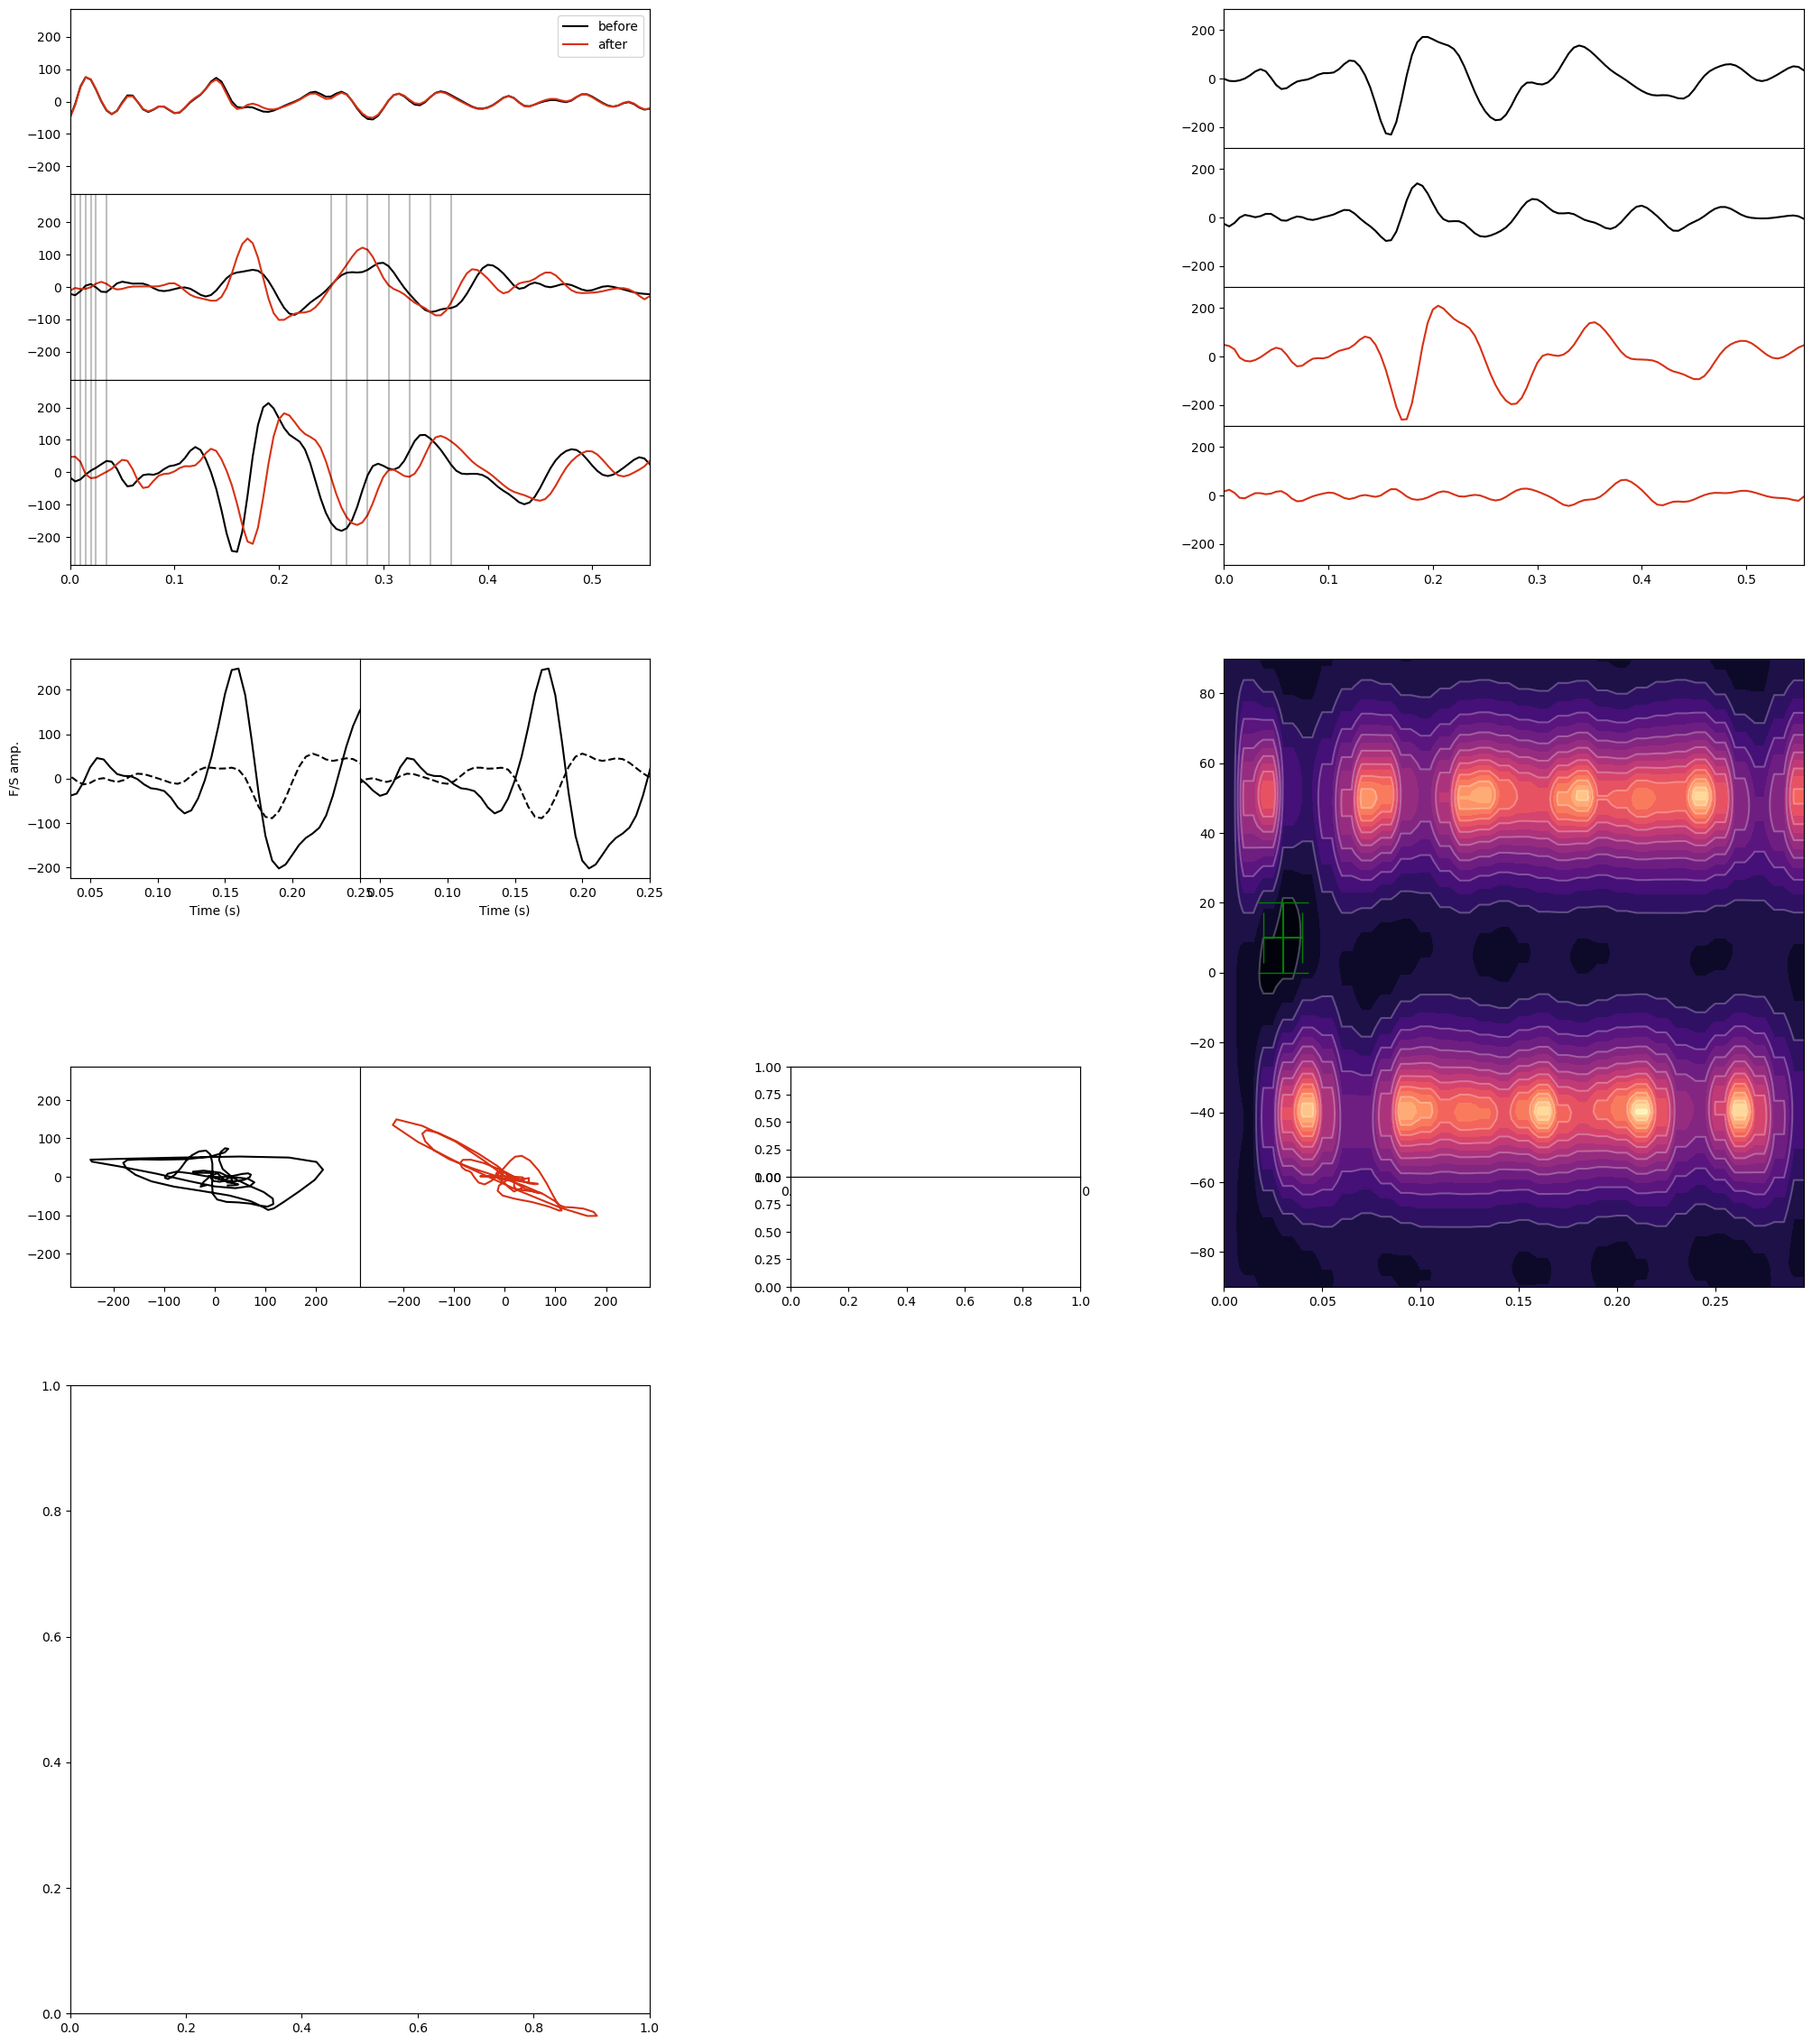

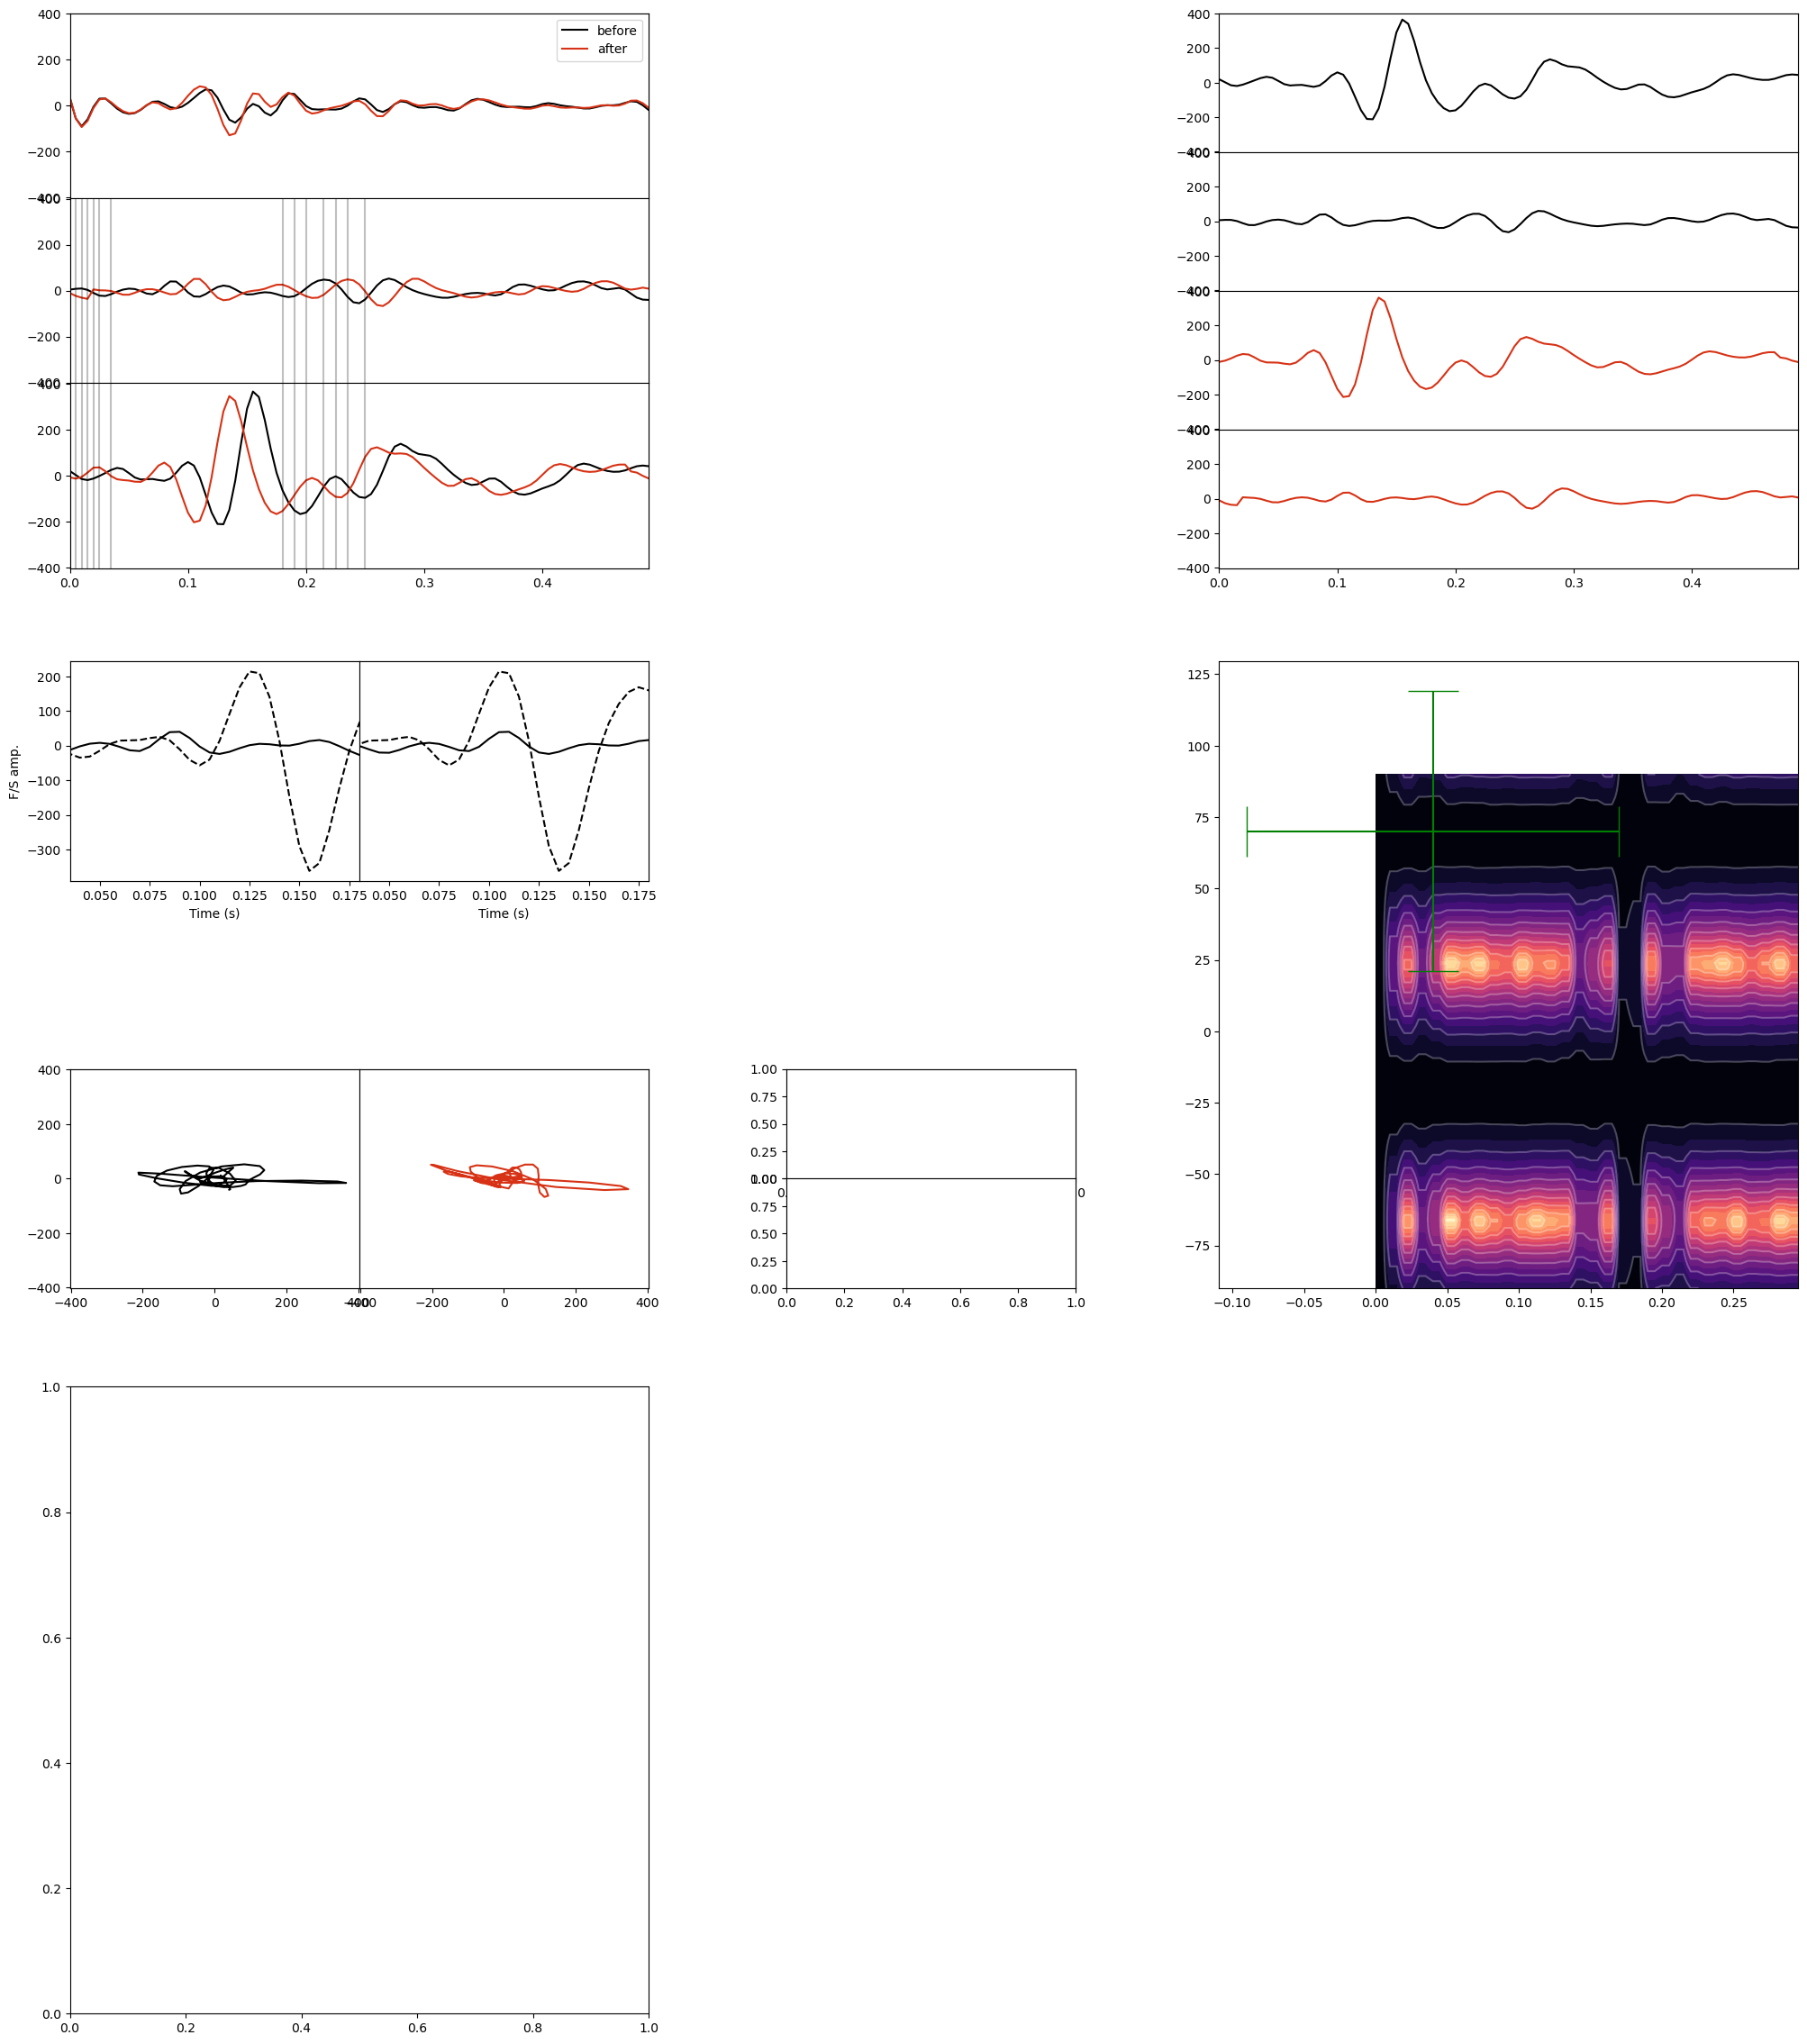

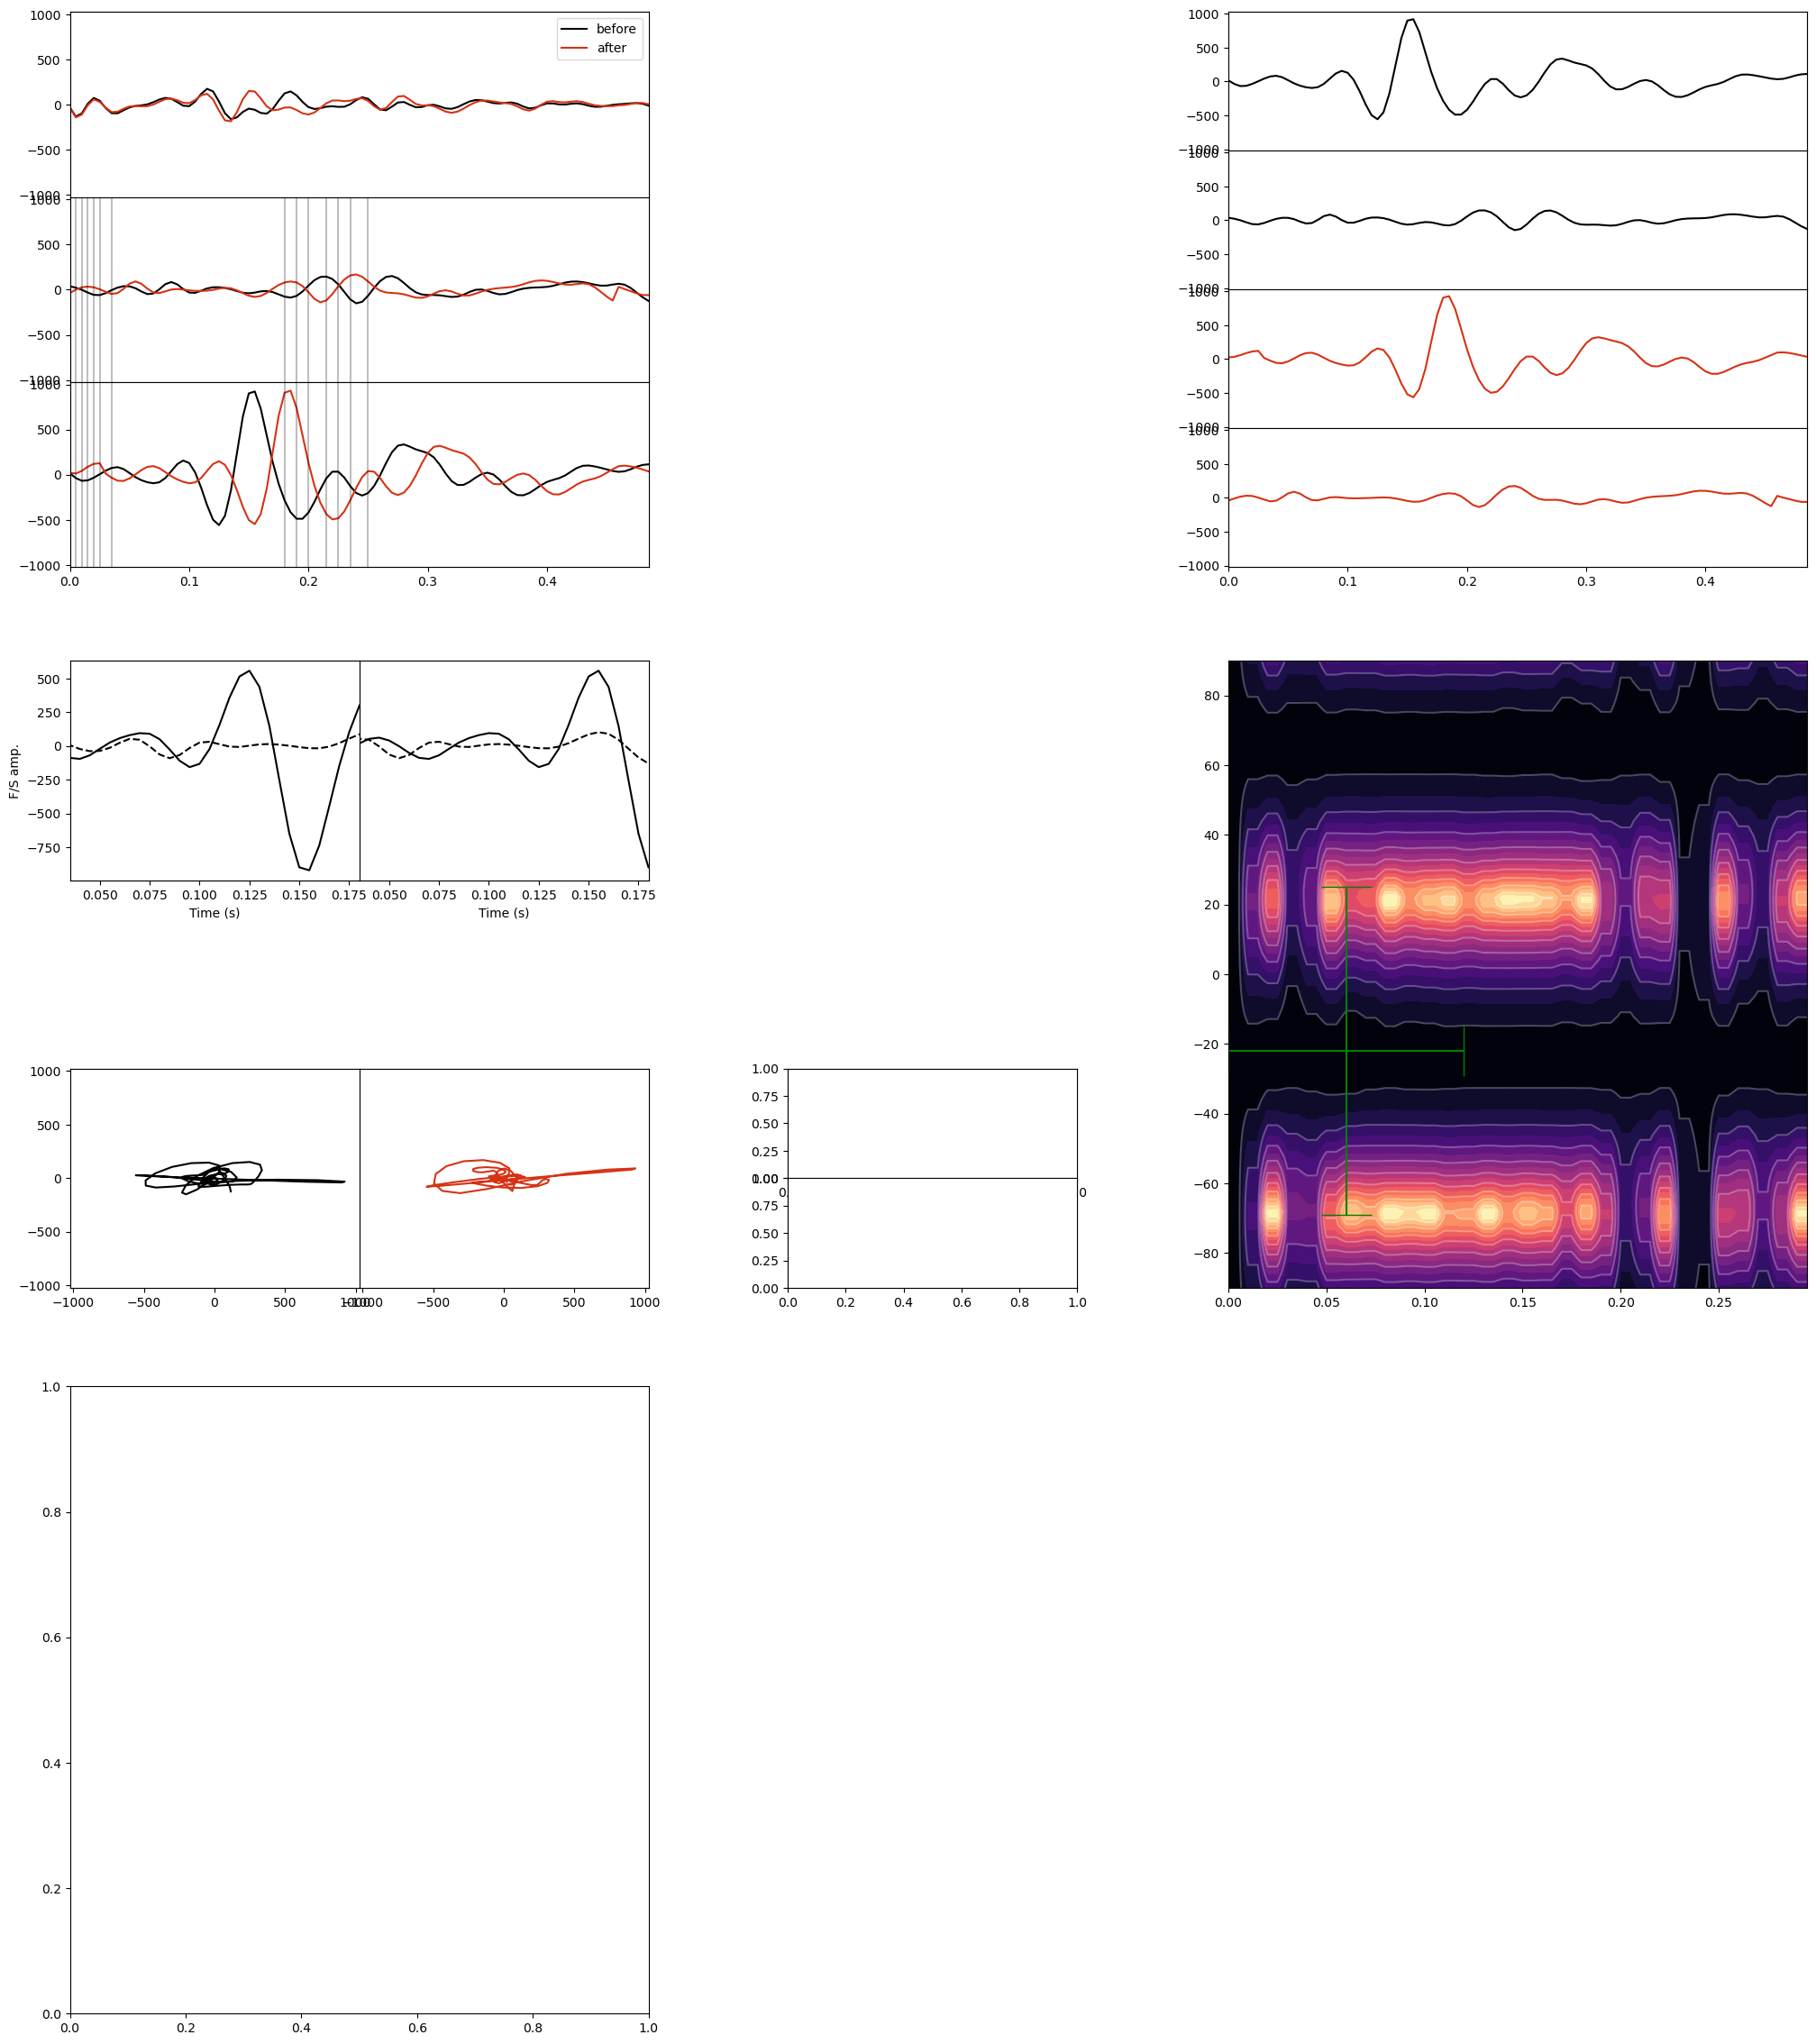

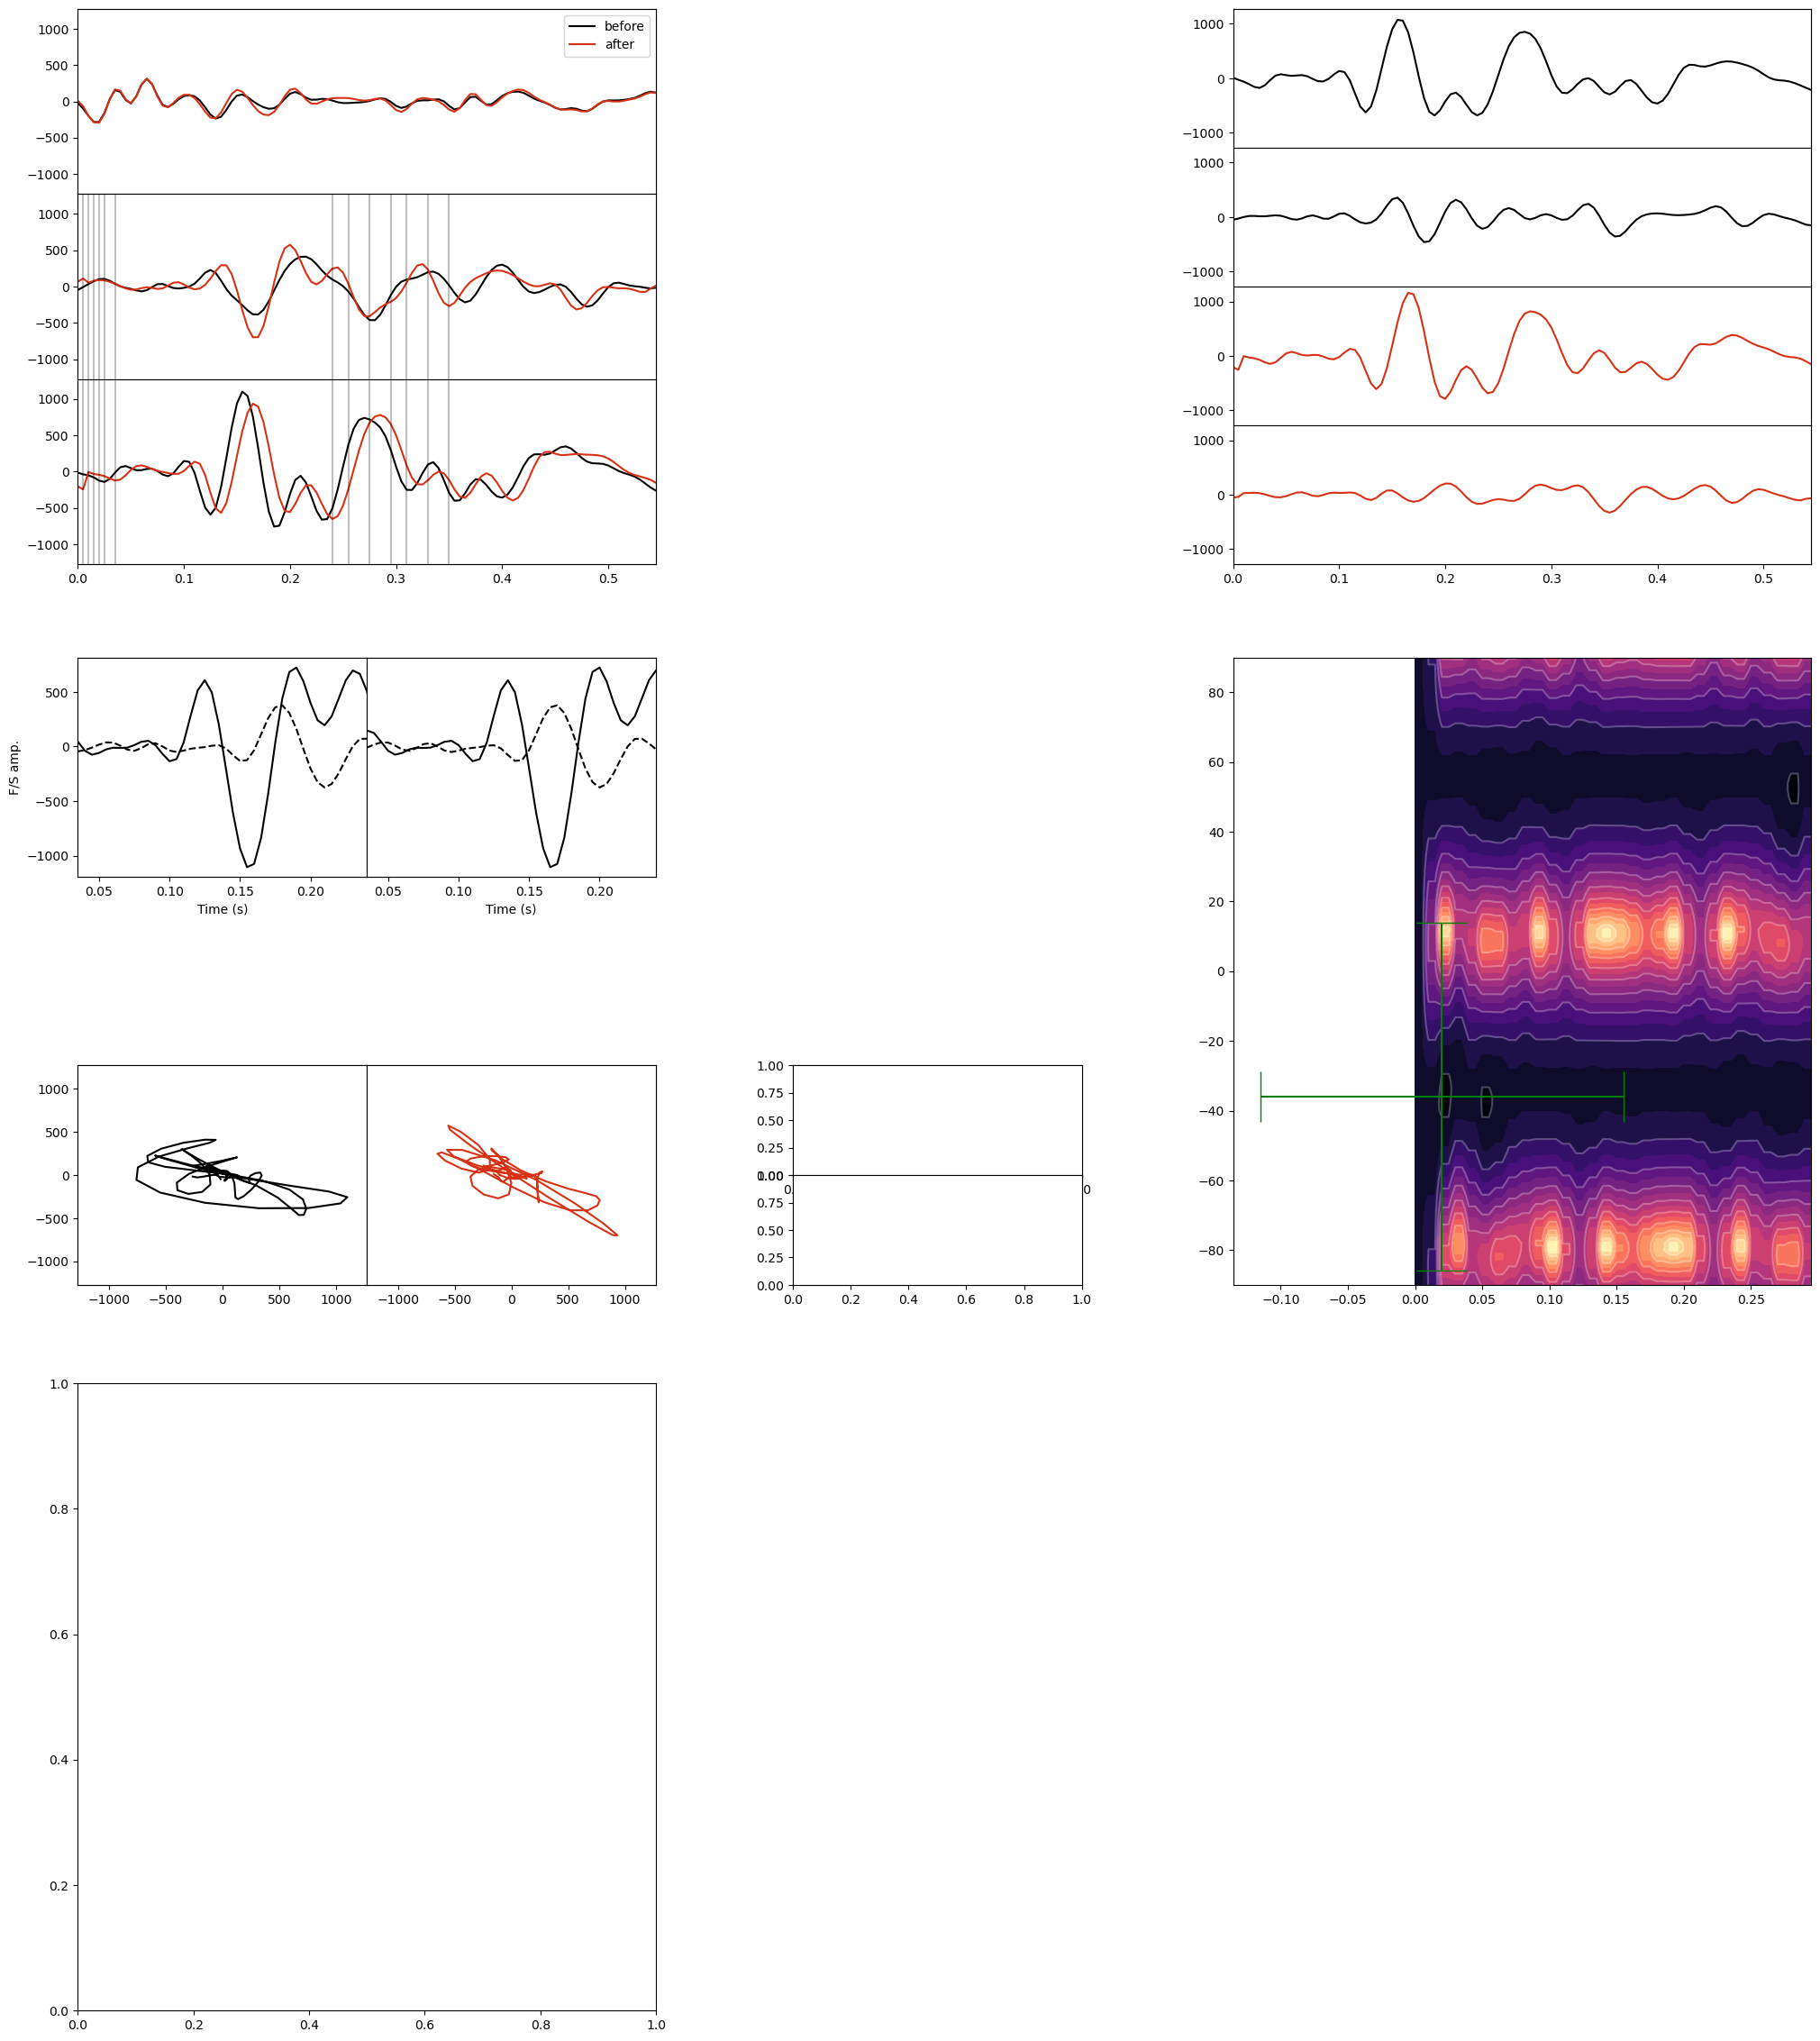

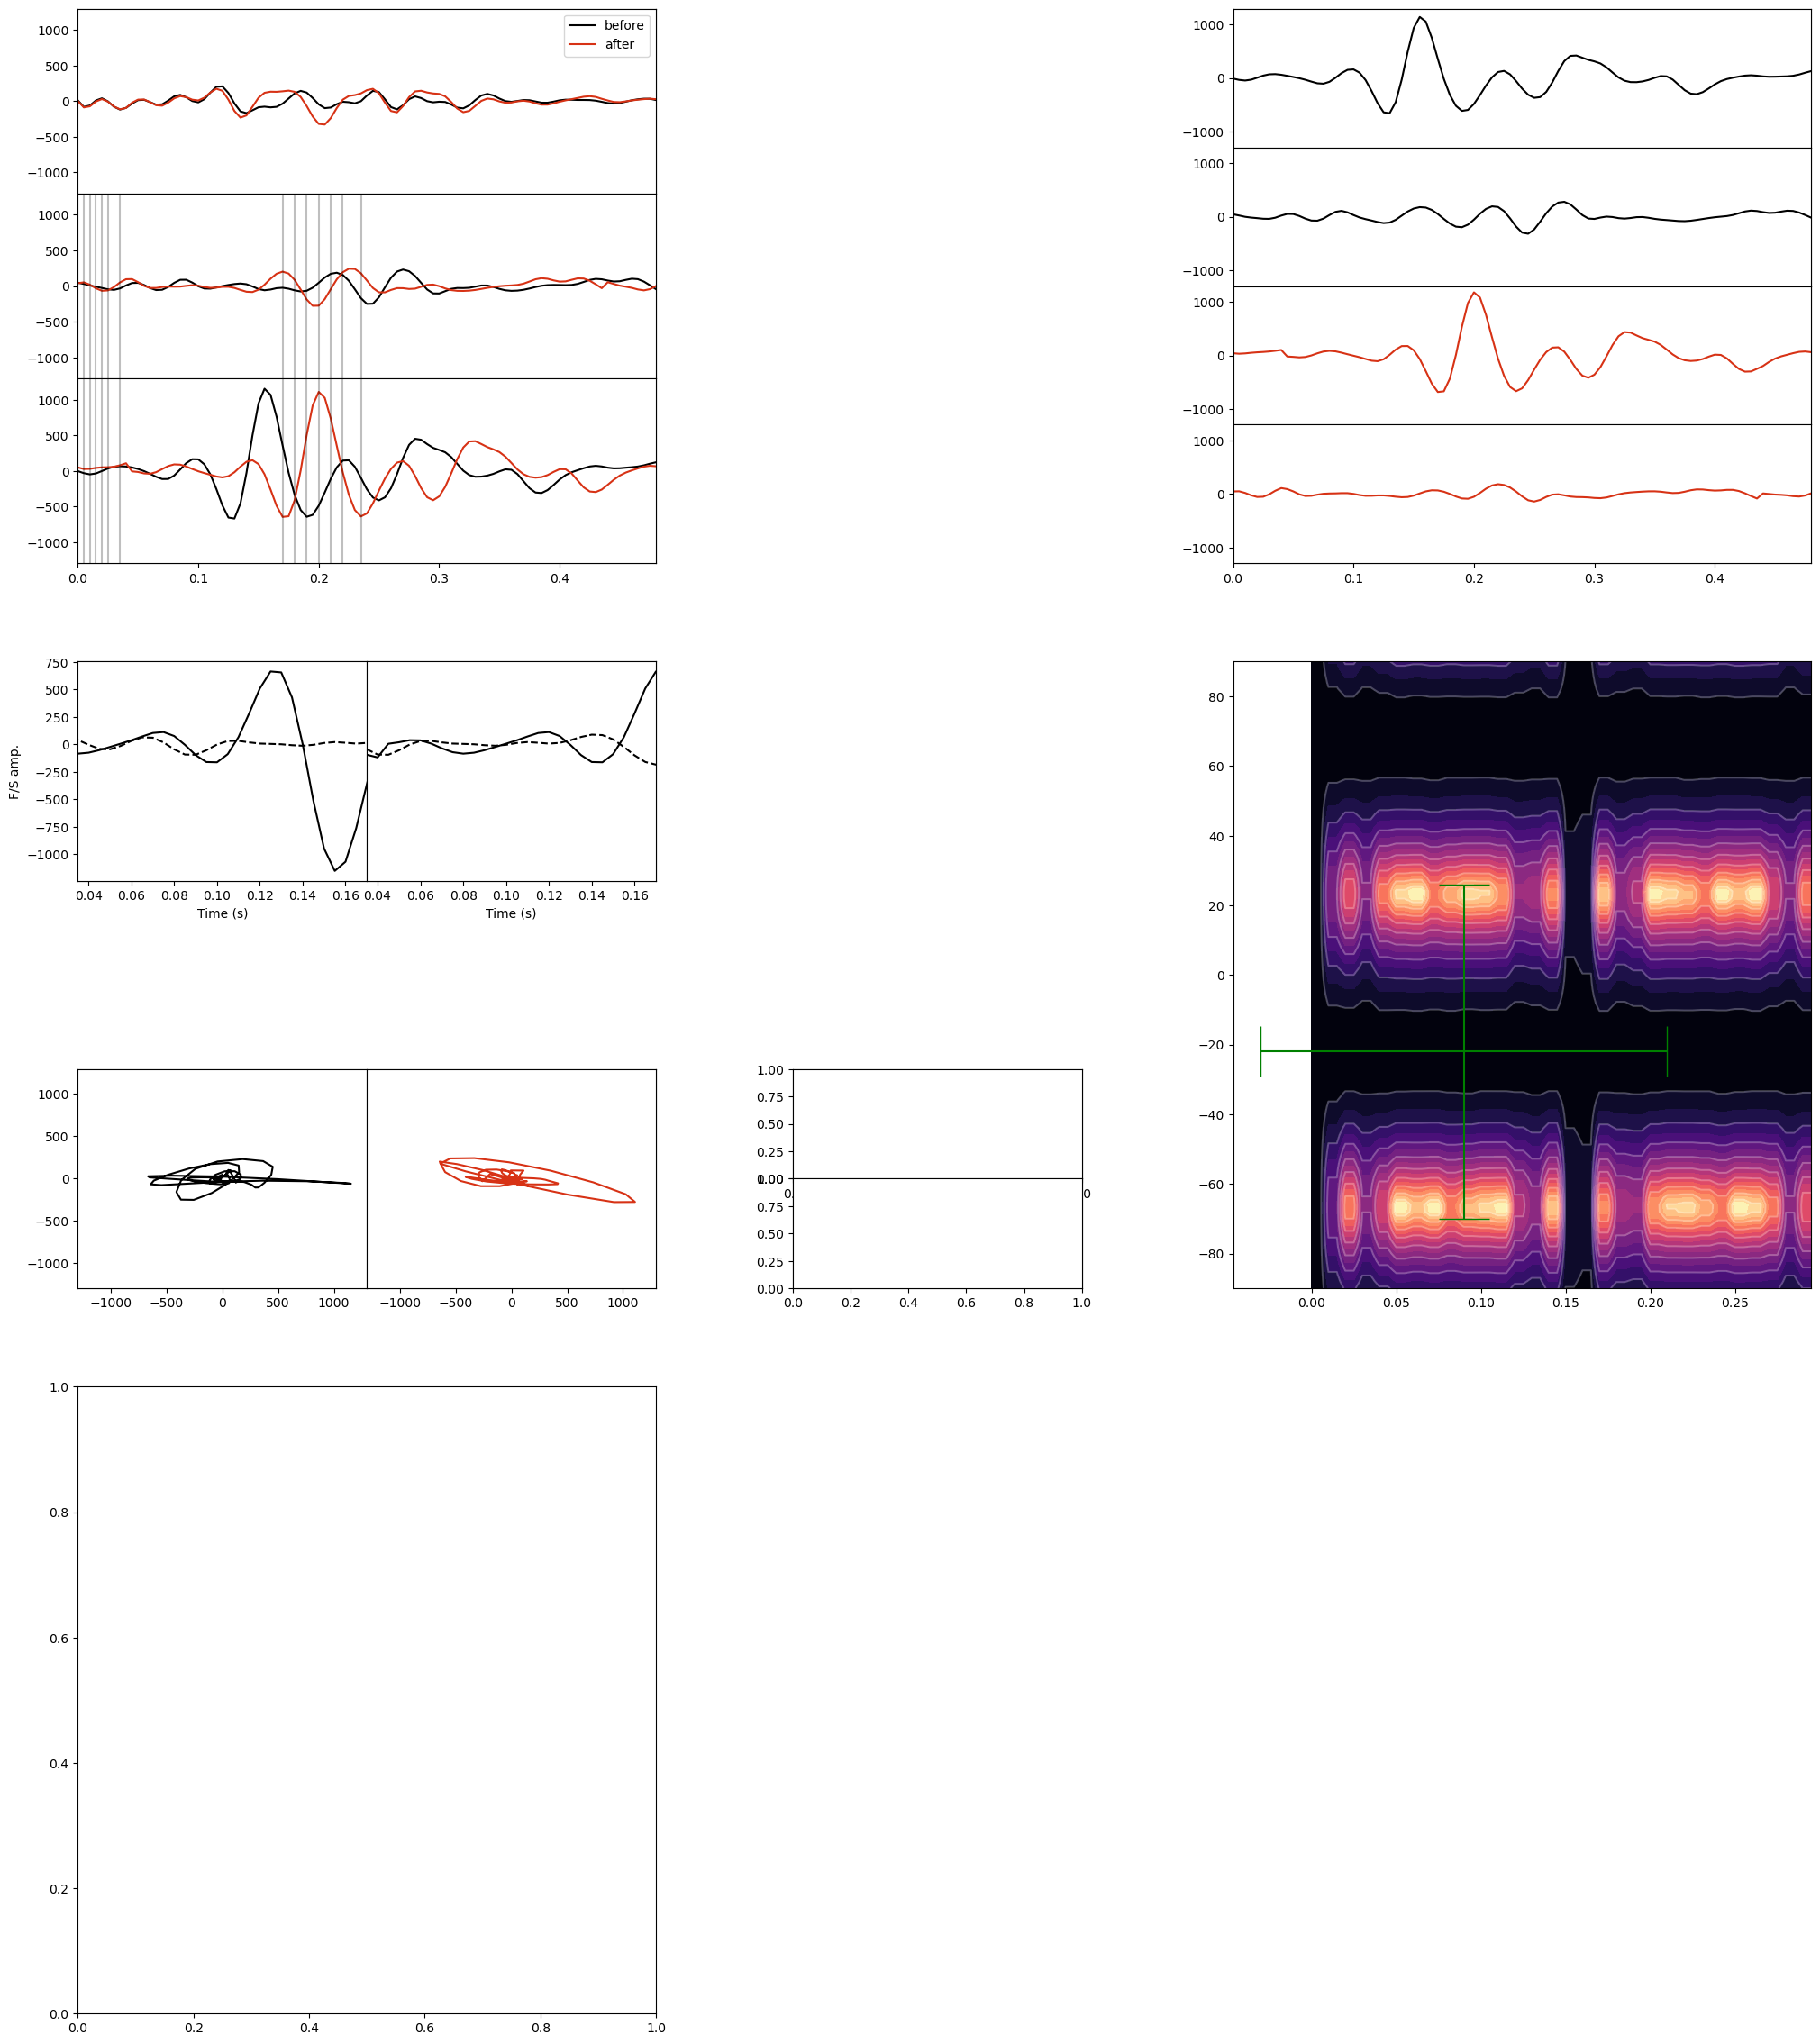

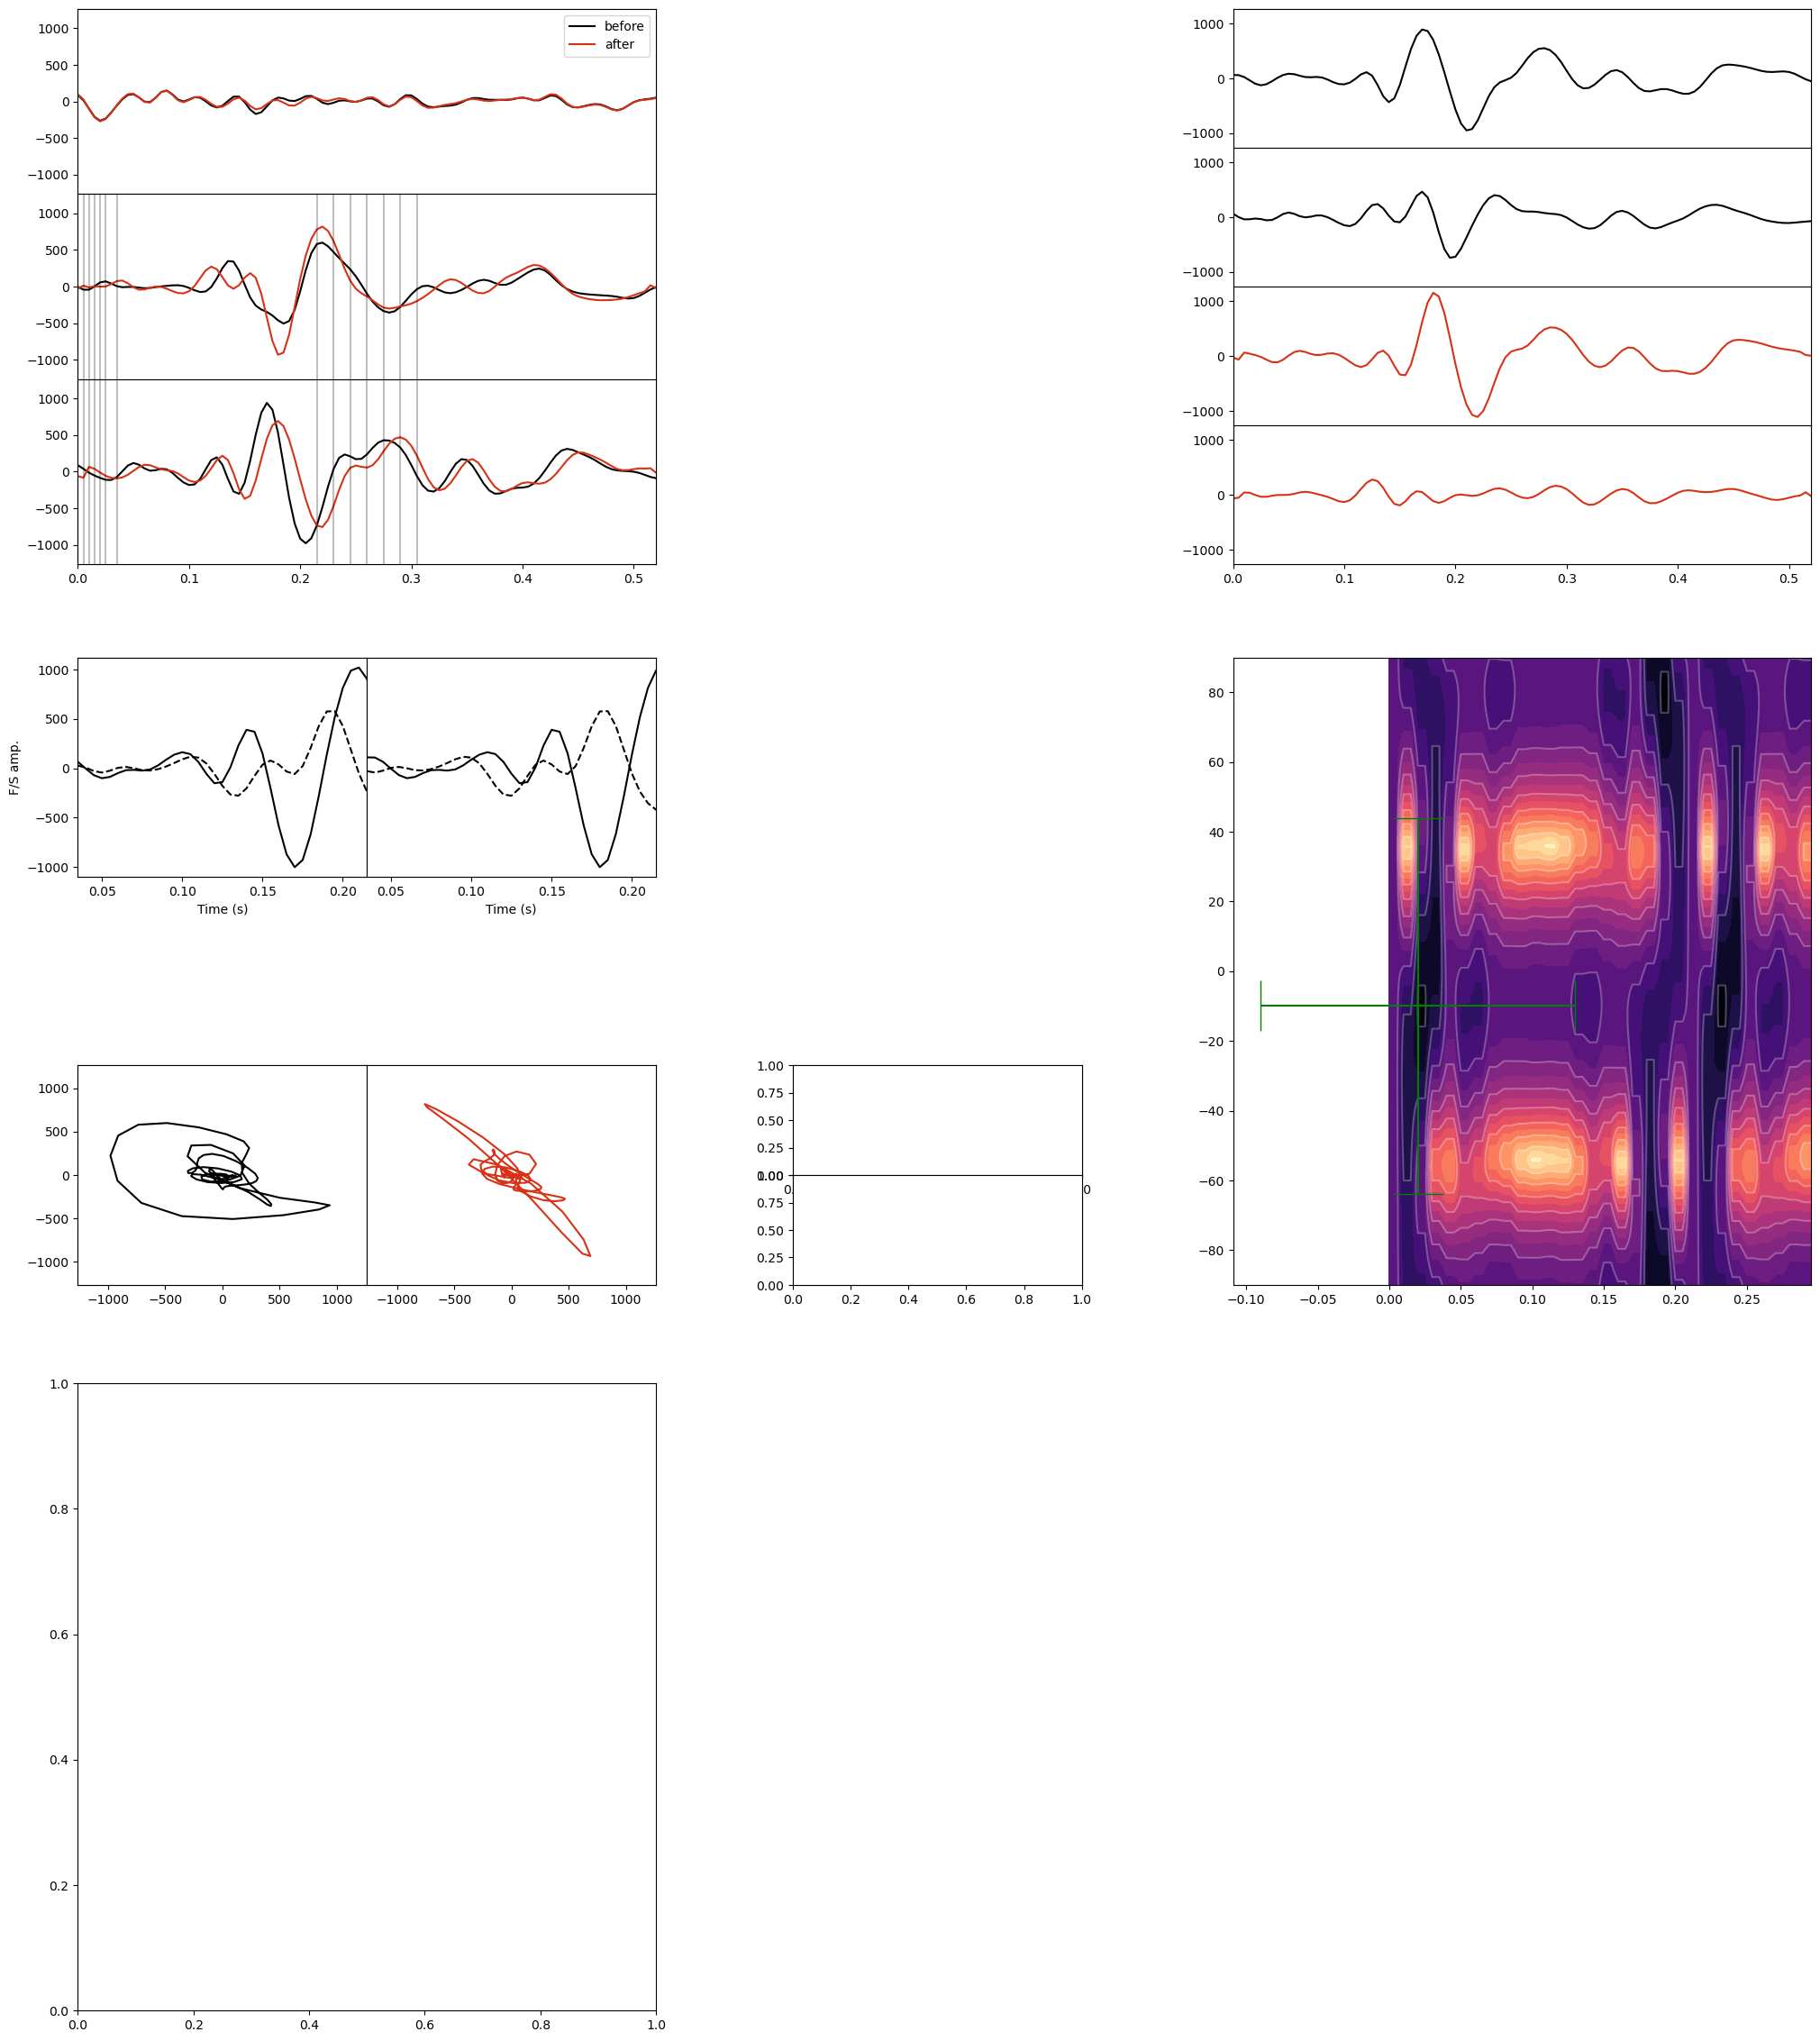

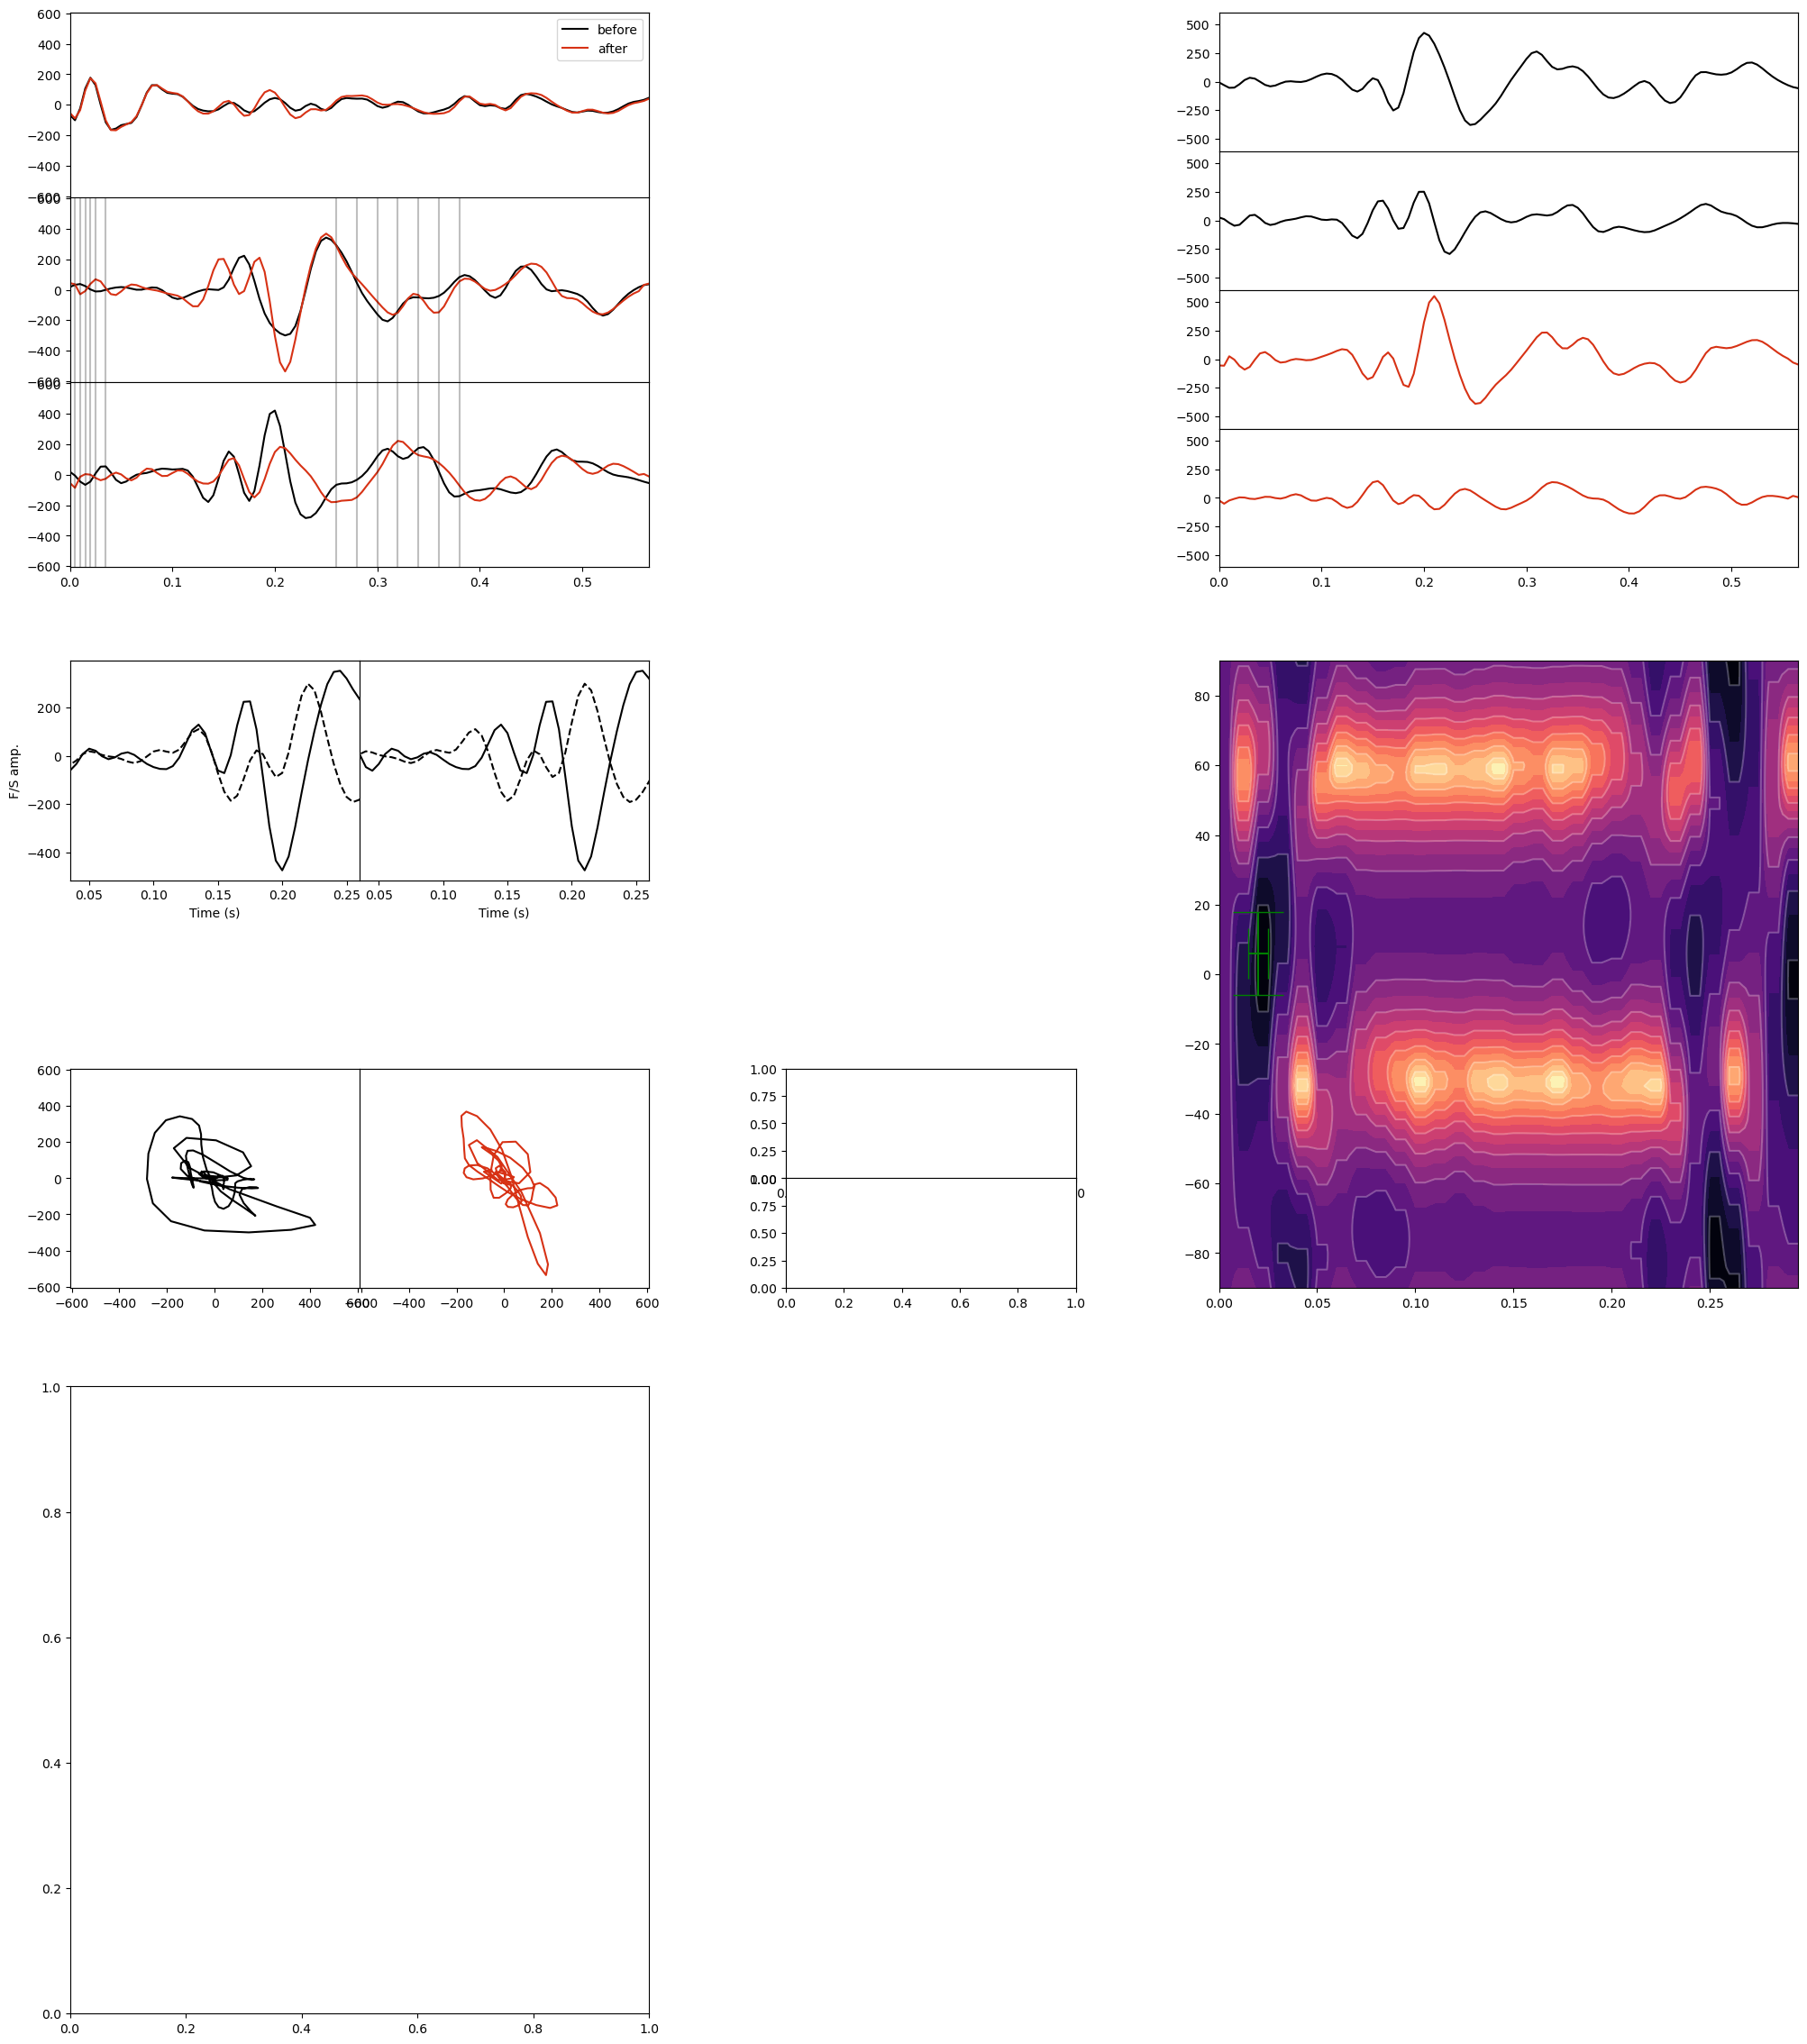

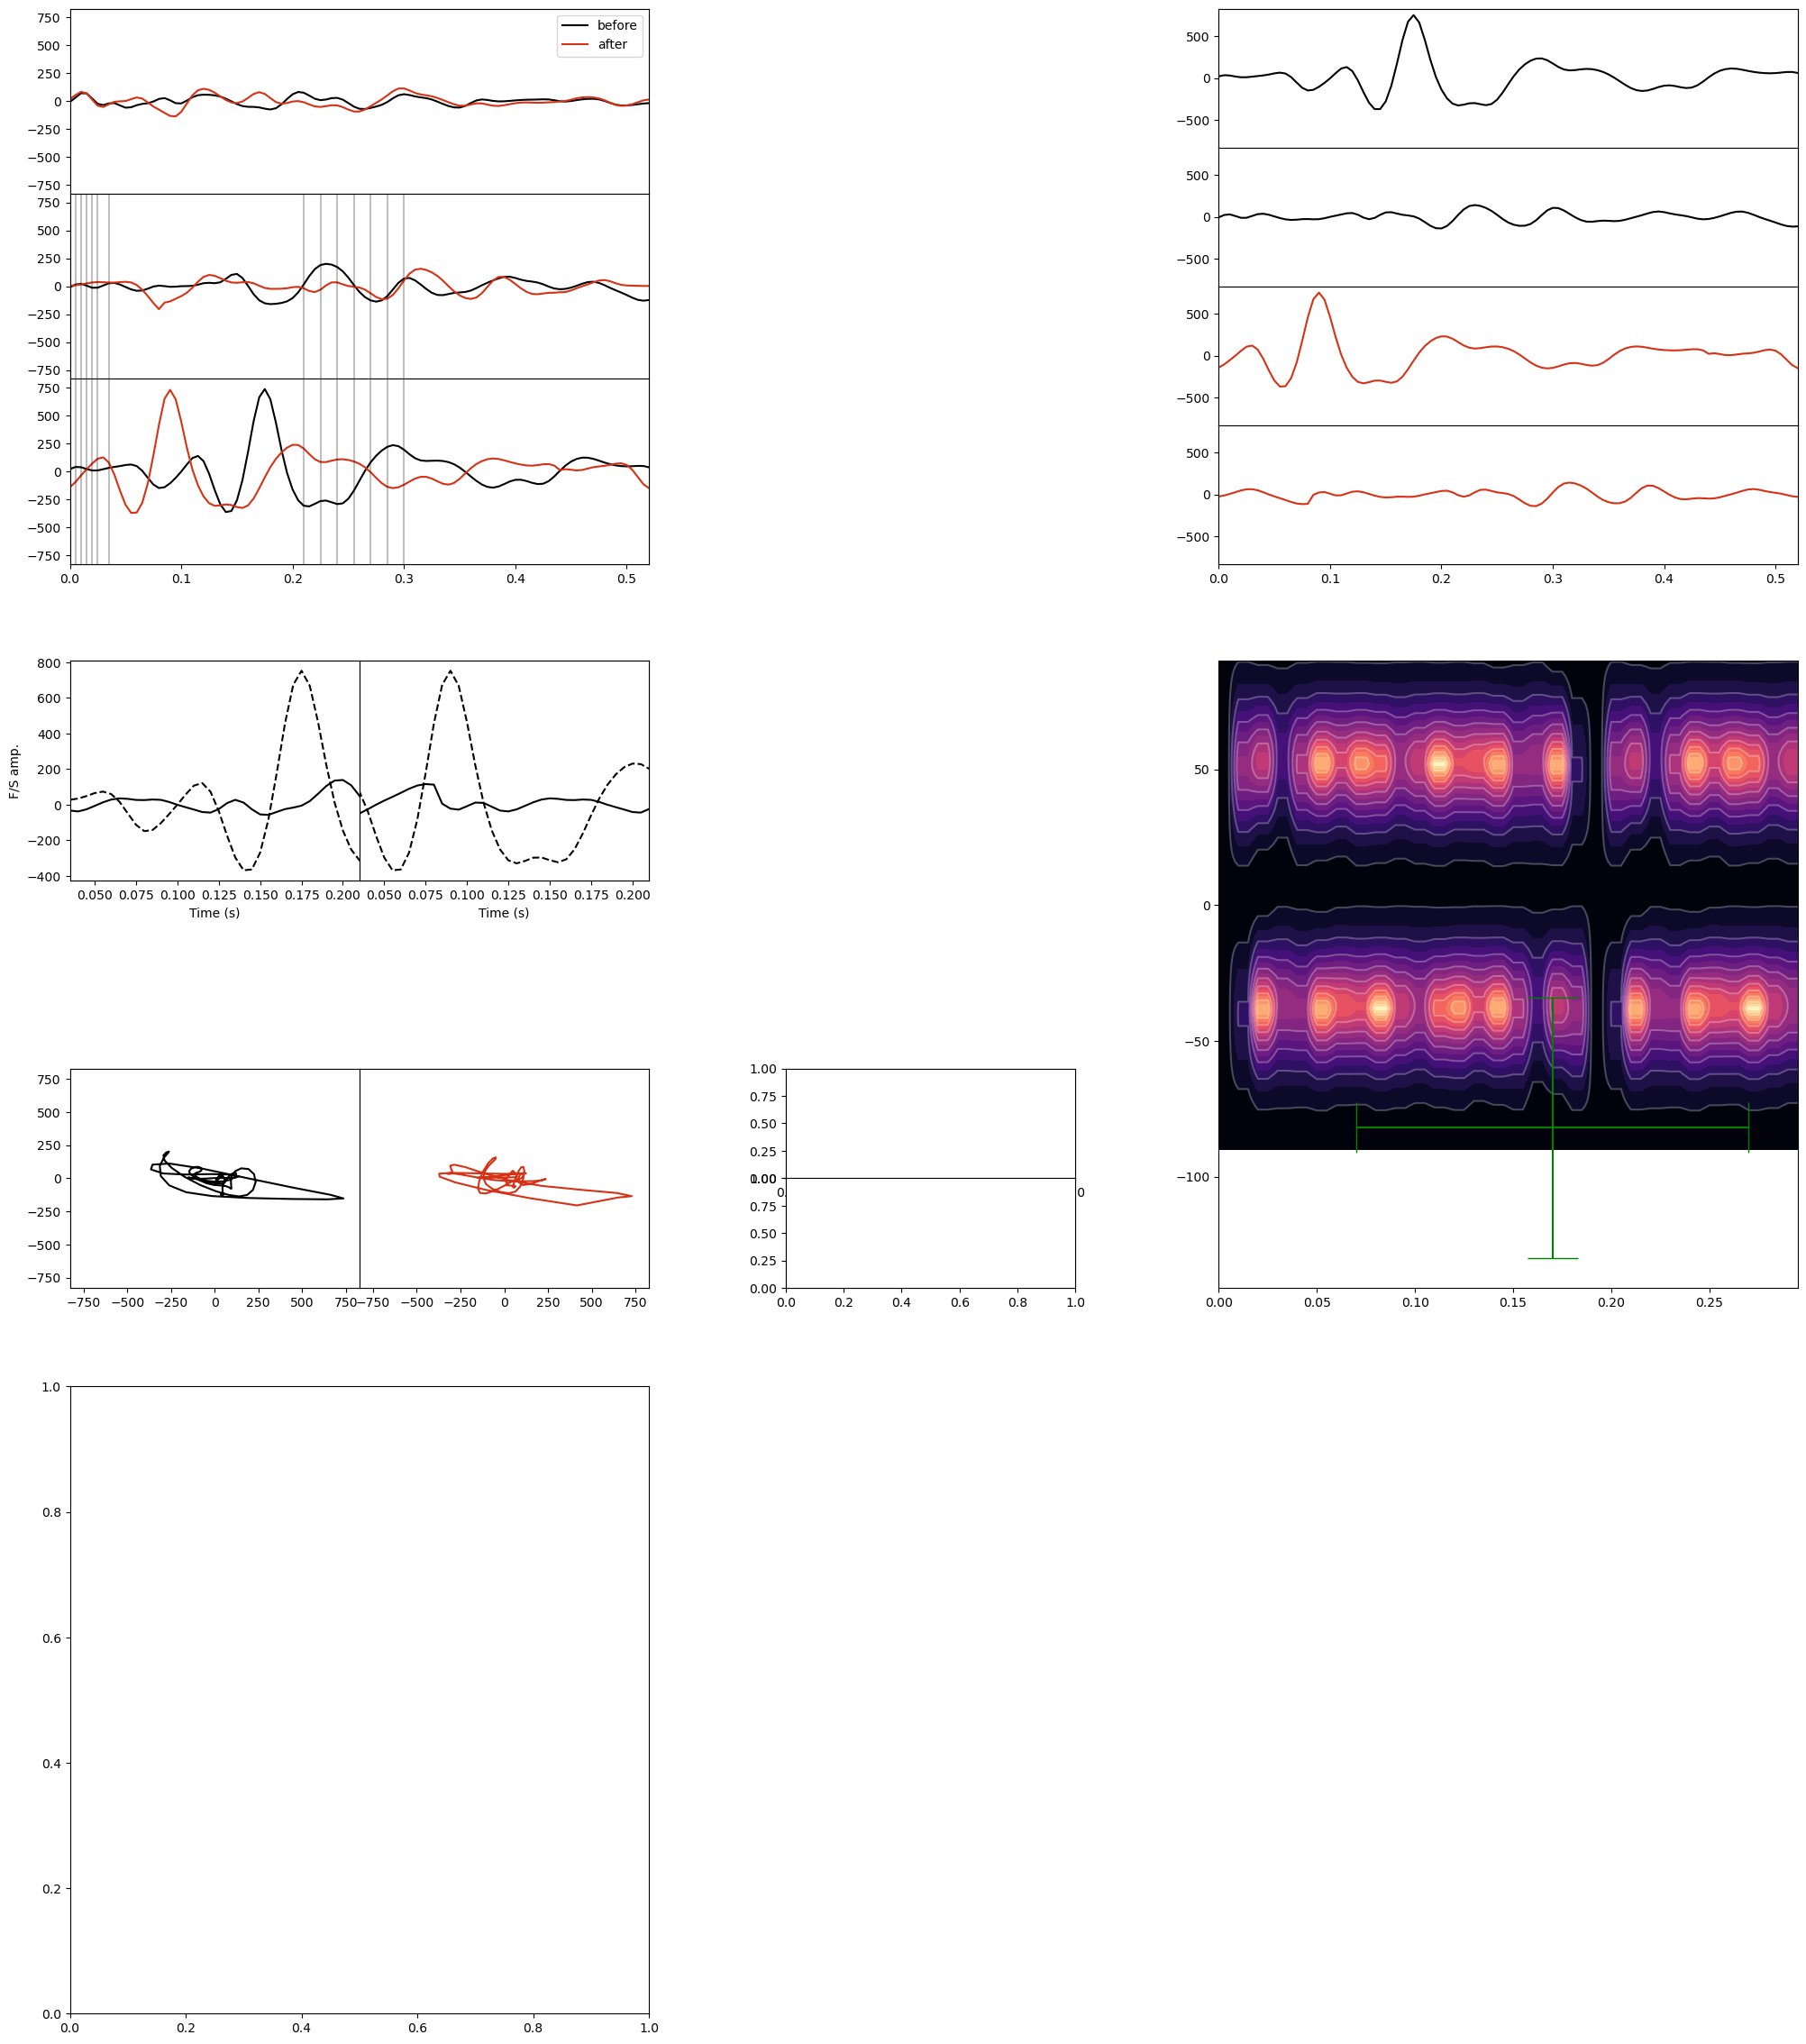

In [43]:
import numpy as np
# Determine the number of batches
num_batches = 1
# Get the keys from the dictionary
keys = list(passing_waveforms.keys())
# Split the keys into batches
key_batches = np.array_split(keys, num_batches)

# Create a list of dictionaries, where each dictionary is a batch of waveforms
batched_waveforms = []
for batch_keys in key_batches:
    batch = {key: passing_waveforms[key] for key in batch_keys}
    batched_waveforms.append(batch)

# You can now iterate over `batched_waveforms` and process each batch
for i, batch in enumerate(batched_waveforms):
    print(f"Processing batch {i+1}/{num_batches} with {len(batch)} waveforms")
    
all_results = []
for i, batch in enumerate(batched_waveforms):
    if i > 1:
        continue

    print(f"Processing batch {i+1}/{num_batches} with {len(batch)} waveforms")
    results_swspy = perform_splitting_on_organized_waveforms(
        batch, 
        first_window_start=2, 
        last_window_start=1,
        first_window_end=1.5, 
        last_window_end=2.5, 
        n_win= 7, 
        s_pick_uncertainty=0.0395, # Kaiwen's MLdd catalog S-pick uncertainty
        plot_results=True
    )
    all_results.append(results_swspy)
    # Optionally, save intermediate results
    #save_results_csv(results_swspy, file_name=f'splitting_results_mldd_2015_2021_axec2_batch_{i+1}.csv')
    save_results_csv(results_swspy, file_name=f'splitting_results_mldd_axec2_test_{i+1}.csv')
    

# Combine results if necessary
final_results = {}
for res in all_results:
    final_results.update(res)

#save_results_csv(final_results, file_name='splitting_results_mldd_2015_2021_axec2_all_batches.csv')
save_results_csv(final_results, file_name='splitting_results_mldd_axec2_test_all_batches.csv')

In [44]:
# Load results from CSV for verification
results_df = pd.read_csv('splitting_results_mldd_axec2_test_all_batches.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'splitting_results_mldd_axec2_test_all_batches.csv'